# MNIST Feature Selection: Conv_NN vs GenA_Conv vs GreyW_Conv vs ParticleS_Conv

Federated CNN with GA / GWO / PSO wrapper feature selection, full comparison across 5 train-test splits.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, copy, warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data
y = mnist.target.astype(int)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (70000, 784)
y shape: (70000,)


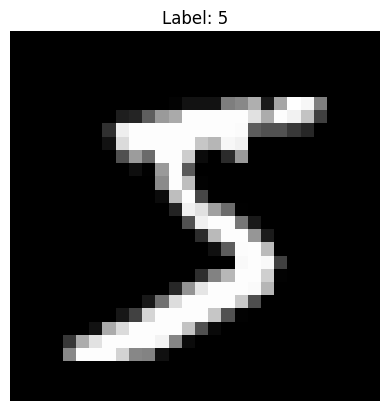

In [3]:
image = X[0].reshape(28, 28)
plt.imshow(image, cmap='gray')
plt.title(f"Label: {y[0]}")
plt.axis('off')
plt.show()

In [4]:
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [5]:
# Normalize → Standardize → Threshold denoise
X_scaled = X / 255.0
mean_val = X_scaled.mean()
std_val  = X_scaled.std()
X_scaled = (X_scaled - mean_val) / std_val
X_scaled = (X_scaled > 0.3).astype('float32')

print("After normalization + standardization + denoising:")
print("Min:", X_scaled.min())
print("Max:", X_scaled.max())
print("Shape:", X_scaled.shape)

After normalization + standardization + denoising:
Min: 0.0
Max: 1.0
Shape: (70000, 784)


In [6]:
splits = [(0.65, 0.35), (0.70, 0.30), (0.75, 0.25), (0.80, 0.20), (0.85, 0.15)]
print("Splits defined:", splits)

Splits defined: [(0.65, 0.35), (0.7, 0.3), (0.75, 0.25), (0.8, 0.2), (0.85, 0.15)]


## Baseline: Logistic Regression (all 784 raw features)

In [8]:
baseline_results = []
for train_ratio, test_ratio in splits:
    print(f"\nTrain-Test Split: {int(train_ratio*100)}:{int(test_ratio*100)}")
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_ratio, random_state=42, stratify=y)
    model = LogisticRegression(max_iter=1000, solver="lbfgs", n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall    = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1        = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-score :", f1)
    baseline_results.append({
        "Split": f"{int(train_ratio*100)}:{int(test_ratio*100)}",
        "Method": "Baseline LR",
        "Accuracy": accuracy, "Precision": precision,
        "Recall": recall, "F1-score": f1
    })


Train-Test Split: 65:35
Accuracy : 0.9103265306122449
Precision: 0.9100497704745951
Recall   : 0.9103265306122449
F1-score : 0.9101360729428465

Train-Test Split: 70:30
Accuracy : 0.9103809523809524
Precision: 0.9101072395120322
Recall   : 0.9103809523809524
F1-score : 0.9101919032001728

Train-Test Split: 75:25
Accuracy : 0.9123428571428571
Precision: 0.9121148657761258
Recall   : 0.9123428571428571
F1-score : 0.912182350967948

Train-Test Split: 80:20
Accuracy : 0.913
Precision: 0.912789072766919
Recall   : 0.913
F1-score : 0.9128106659196163

Train-Test Split: 85:15
Accuracy : 0.9162857142857143
Precision: 0.9161412334458967
Recall   : 0.9162857142857143
F1-score : 0.9160812218209406


## Federated CNN (FedCNN) — 80:20 split (initial training)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y)
X_train_cnn = X_train.reshape(-1, 1, 28, 28)
X_test_cnn  = X_test.reshape(-1, 1, 28, 28)
print("X_train_cnn shape:", X_train_cnn.shape)
print("X_test_cnn  shape:", X_test_cnn.shape)

X_train_cnn shape: (56000, 1, 28, 28)
X_test_cnn  shape: (14000, 1, 28, 28)


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class FedCNN(nn.Module):
    def __init__(self):
        super(FedCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.feature_layer = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Dropout(0.5)
        )
        self.classifier = nn.Linear(128, 10)

    def forward(self, x, return_features=False):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        features = self.feature_layer(x)
        output = self.classifier(features)
        if return_features:
            return output, features
        return output

model = FedCNN().to(device)
sample_images = torch.tensor(X_train_cnn[:8]).float().to(device)
outputs, features = model(sample_images, return_features=True)
print("Output shape:", outputs.shape)
print("Feature shape:", features.shape)

Using device: cpu
Output shape: torch.Size([8, 10])
Feature shape: torch.Size([8, 128])


In [11]:
def create_federated_clients(X_train_cnn, y_train, num_clients=5):
    clients = []
    total_samples = len(X_train_cnn)
    samples_per_client = total_samples // num_clients
    for i in range(num_clients):
        start = i * samples_per_client
        end = total_samples if i == num_clients - 1 else start + samples_per_client
        X_tensor = torch.tensor(X_train_cnn[start:end]).float()
        y_tensor = torch.tensor(y_train[start:end]).long()
        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset, batch_size=64, shuffle=True)
        clients.append(loader)
        print(f"Client {i+1}: {len(dataset)} samples")
    return clients

clients = create_federated_clients(X_train_cnn, y_train, num_clients=5)

Client 1: 11200 samples
Client 2: 11200 samples
Client 3: 11200 samples
Client 4: 11200 samples
Client 5: 11200 samples


In [12]:
class ClientSelectorQAgent:
    def __init__(self, num_clients):
        self.q_table = np.zeros(num_clients)
    def select_clients(self, k=3):
        return np.argsort(self.q_table)[-k:]
    def update(self, selected_indices, rewards):
        for idx, reward in zip(selected_indices, rewards):
            self.q_table[idx] += reward

agent = ClientSelectorQAgent(num_clients=5)
selected = agent.select_clients(k=3)
print("Selected clients:", selected)
print("Q-table:", agent.q_table)

Selected clients: [2 3 4]
Q-table: [0. 0. 0. 0. 0.]


In [13]:
def train_one_client(model, client_loader, epochs=2, learning_rate=0.001):
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    for epoch in range(epochs):
        for images, labels in client_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
    return model

def evaluate_cnn_model(model, X_data, y_data, batch_size=256):
    model.eval()
    dataset = TensorDataset(torch.tensor(X_data).float(), torch.tensor(y_data).long())
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            preds = torch.argmax(model(images), dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    accuracy  = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall    = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1        = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    report    = classification_report(all_labels, all_preds, zero_division=0)
    return accuracy, precision, recall, f1, report

def federated_average(global_model, client_models):
    global_state = global_model.state_dict()
    for key in global_state.keys():
        global_state[key] = torch.stack(
            [cm.state_dict()[key].float() for cm in client_models], dim=0).mean(dim=0)
    global_model.load_state_dict(global_state)
    return global_model

def extract_cnn_features(model, X_data, y_data, batch_size=256):
    model.eval()
    dataset = TensorDataset(torch.tensor(X_data).float(), torch.tensor(y_data).long())
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_features, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            _, feats = model(images, return_features=True)
            all_features.append(feats.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.vstack(all_features), np.array(all_labels)

print("Helper functions defined")

Helper functions defined


Client 1: 9520 samples
Client 2: 9520 samples
Client 3: 9520 samples
Client 4: 9520 samples
Client 5: 9520 samples

Federated Round 1/5
  Client 3 val accuracy: 0.9527
  Client 4 val accuracy: 0.9390
  Client 5 val accuracy: 0.9543
  Global accuracy (sample): 0.9337

Federated Round 2/5
  Client 4 val accuracy: 0.9623
  Client 3 val accuracy: 0.9680
  Client 5 val accuracy: 0.9610
  Global accuracy (sample): 0.9707

Federated Round 3/5
  Client 4 val accuracy: 0.9617
  Client 5 val accuracy: 0.9663
  Client 3 val accuracy: 0.9663
  Global accuracy (sample): 0.9777

Federated Round 4/5
  Client 4 val accuracy: 0.9750
  Client 5 val accuracy: 0.9737
  Client 3 val accuracy: 0.9713
  Global accuracy (sample): 0.9823

Federated Round 5/5
  Client 4 val accuracy: 0.9717
  Client 5 val accuracy: 0.9763
  Client 3 val accuracy: 0.9787
  Global accuracy (sample): 0.9800


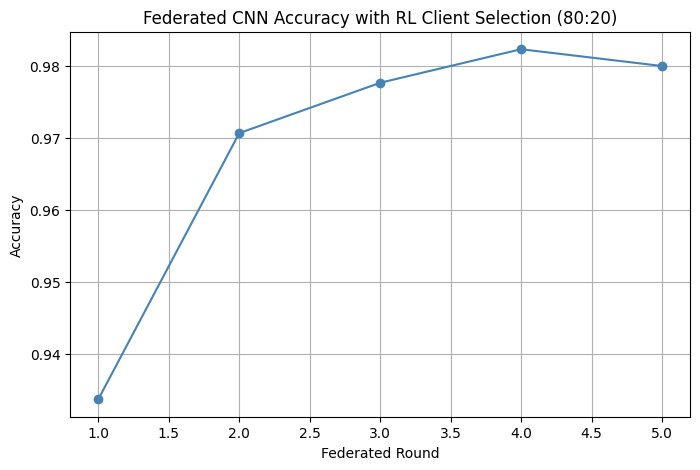

In [14]:
X_train_fl, X_val_cnn, y_train_fl, y_val = train_test_split(
    X_train_cnn, y_train, test_size=0.15, random_state=42, stratify=y_train)
clients = create_federated_clients(X_train_fl, y_train_fl, num_clients=5)
agent = ClientSelectorQAgent(num_clients=len(clients))
global_model = FedCNN().to(device)

num_rounds = 5
round_accuracy, round_precision, round_recall, round_f1 = [], [], [], []

for round_no in range(num_rounds):
    print(f"\nFederated Round {round_no+1}/{num_rounds}")
    selected_indices = agent.select_clients(k=3)
    client_models, rewards = [], []
    for idx in selected_indices:
        client_model = copy.deepcopy(global_model).to(device)
        client_model = train_one_client(client_model, clients[idx], epochs=1)
        val_acc, _, _, _, _ = evaluate_cnn_model(client_model, X_val_cnn[:3000], y_val[:3000])
        rewards.append(val_acc)
        client_models.append(client_model)
        print(f"  Client {idx+1} val accuracy: {val_acc:.4f}")
    global_model = federated_average(global_model, client_models)
    agent.update(selected_indices, rewards)
    acc, prec, rec, f1, _ = evaluate_cnn_model(global_model, X_test_cnn[:3000], y_test[:3000])
    round_accuracy.append(acc); round_precision.append(prec)
    round_recall.append(rec); round_f1.append(f1)
    print(f"  Global accuracy (sample): {acc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_rounds + 1), round_accuracy, marker="o", color='steelblue')
plt.xlabel("Federated Round"); plt.ylabel("Accuracy")
plt.title("Federated CNN Accuracy with RL Client Selection (80:20)")
plt.grid(True); plt.show()

In [15]:
final_acc, final_prec, final_rec, final_f1, final_report = evaluate_cnn_model(
    global_model, X_test_cnn, y_test)
print("Final Federated CNN Accuracy  :", final_acc)
print("Final Federated CNN Precision :", final_prec)
print("Final Federated CNN Recall    :", final_rec)
print("Final Federated CNN F1-score  :", final_f1)
print("\nClassification Report:")
print(final_report)

Final Federated CNN Accuracy  : 0.9800714285714286
Final Federated CNN Precision : 0.9801863125765747
Final Federated CNN Recall    : 0.9800714285714286
Final Federated CNN F1-score  : 0.9800709287648329

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1381
           1       0.99      0.98      0.99      1575
           2       0.97      0.98      0.97      1398
           3       0.99      0.98      0.98      1428
           4       0.98      0.98      0.98      1365
           5       1.00      0.97      0.98      1263
           6       0.98      0.99      0.98      1375
           7       0.97      0.98      0.98      1459
           8       0.98      0.97      0.97      1365
           9       0.98      0.97      0.97      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



## Conv_NN — CNN Feature Classifier (all 128 CNN features, no selection)

In [16]:
X_train_features, y_train_features = extract_cnn_features(global_model, X_train_cnn, y_train)
X_test_features,  y_test_features  = extract_cnn_features(global_model, X_test_cnn,  y_test)
print("Train CNN features shape:", X_train_features.shape)
print("Test  CNN features shape:", X_test_features.shape)

Train CNN features shape: (56000, 128)
Test  CNN features shape: (14000, 128)


In [17]:
feature_scaler = StandardScaler()
X_train_features_scaled = feature_scaler.fit_transform(X_train_features)
X_test_features_scaled  = feature_scaler.transform(X_test_features)

conv_nn_model = LogisticRegression(max_iter=1000, solver="lbfgs", n_jobs=-1)
conv_nn_model.fit(X_train_features_scaled, y_train_features)
conv_nn_preds = conv_nn_model.predict(X_test_features_scaled)

conv_nn_acc  = accuracy_score(y_test_features, conv_nn_preds)
conv_nn_prec = precision_score(y_test_features, conv_nn_preds, average="weighted", zero_division=0)
conv_nn_rec  = recall_score(y_test_features,  conv_nn_preds, average="weighted", zero_division=0)
conv_nn_f1   = f1_score(y_test_features,  conv_nn_preds, average="weighted", zero_division=0)

print("Method: Conv_NN (all 128 features)")
print(f"Accuracy : {conv_nn_acc:.4f}")
print(f"Precision: {conv_nn_prec:.4f}")
print(f"Recall   : {conv_nn_rec:.4f}")
print(f"F1-score : {conv_nn_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_features, conv_nn_preds, zero_division=0))

Method: Conv_NN (all 128 features)
Accuracy : 0.9856
Precision: 0.9857
Recall   : 0.9856
F1-score : 0.9856

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1381
           1       0.99      0.99      0.99      1575
           2       0.99      0.98      0.98      1398
           3       0.99      0.98      0.99      1428
           4       0.99      0.98      0.99      1365
           5       0.99      0.99      0.99      1263
           6       0.99      0.98      0.99      1375
           7       0.98      0.99      0.98      1459
           8       0.98      0.98      0.98      1365
           9       0.98      0.98      0.98      1391

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000



In [18]:
# CNN Hyperparameter Summary
cnn_hyperparameters = {
    "Input Image Size": "28 x 28", "Input Channels": 1,
    "Conv Layer 1 Filters": 32, "Conv Layer 1 Kernel": "3x3", "Conv Layer 1 BatchNorm": "Yes",
    "Conv Layer 2 Filters": 64, "Conv Layer 2 Kernel": "3x3", "Conv Layer 2 BatchNorm": "Yes",
    "Activation": "ReLU", "Pooling": "MaxPool2d (2x2)", "Dropout": "0.5",
    "CNN Feature Vector Size": 128, "Output Classes": 10,
    "Optimizer": "Adam", "Learning Rate": 0.001,
    "Batch Size": 64, "Local Epochs per Client": 2,
    "Federated Rounds (initial)": 5, "Federated Rounds (multi-split)": 3,
    "Num Clients": 5, "Clients Selected per Round": 3,
    "Preprocessing": "Normalize + Standardize + Threshold Denoise"
}
pd.DataFrame(list(cnn_hyperparameters.items()), columns=["Hyperparameter","Value"])

,Hyperparameter,Value
0,Input Image Size,28 x 28
1,Input Channels,1
2,Conv Layer 1 Filters,32
3,Conv Layer 1 Kernel,3x3
4,Conv Layer 1 BatchNorm,Yes
5,Conv Layer 2 Filters,64
6,Conv Layer 2 Kernel,3x3
7,Conv Layer 2 BatchNorm,Yes
8,Activation,ReLU
9,Pooling,MaxPool2d (2x2)


## Wrapper Feature Selection — Common Setup

In [19]:
X_fs_train, X_fs_val, y_fs_train, y_fs_val = train_test_split(
    X_train_features_scaled, y_train_features,
    test_size=0.20, random_state=42, stratify=y_train_features)

X_fs_train_small = X_fs_train[:8000]
y_fs_train_small = y_fs_train[:8000]
X_fs_val_small   = X_fs_val[:3000]
y_fs_val_small   = y_fs_val[:3000]

print("Feature selection train:", X_fs_train_small.shape)
print("Feature selection val  :", X_fs_val_small.shape)

Feature selection train: (8000, 128)
Feature selection val  : (3000, 128)


In [20]:
def evaluate_feature_mask(mask, X_train, y_train, X_val, y_val):
    """
    Wrapper fitness function: accuracy minus a small feature-count penalty.
    Returns 0 if no features selected.
    """
    selected_features = np.where(mask == 1)[0]
    if len(selected_features) == 0:
        return 0.0
    model = LogisticRegression(max_iter=500, solver="lbfgs", n_jobs=-1)
    model.fit(X_train[:, selected_features], y_train)
    preds = model.predict(X_val[:, selected_features])
    accuracy = accuracy_score(y_val, preds)
    feature_penalty = len(selected_features) / len(mask)
    return accuracy - 0.005 * feature_penalty

print("Fitness function defined")

Fitness function defined


## GenA_Conv — Genetic Algorithm Feature Selection

### Algorithm Overview
**Genetic Algorithm (GA)** mimics biological evolution. Each *chromosome* is a binary mask over the 128 CNN features. The population evolves through:

| Step | Operation | Detail |
|------|-----------|--------|
| Initialisation | Random binary population | `population_size` chromosomes, each of length `num_features` |
| Selection | Truncation / elitist selection | Top 50% parents survive each generation |
| Crossover | Single-point crossover | Random pivot splits two parents; offspring inherits left from parent1, right from parent2 |
| Mutation | Bit-flip mutation | Each bit flipped with probability `mutation_rate` |
| Fitness | Wrapper accuracy − penalty | LR accuracy on val set minus 0.005 × feature_fraction |

**Hyperparameters used:**  population = 12, generations = 8, mutation_rate = 0.05

In [21]:
def cnn_ga_feature_selection(
    X_train, y_train, X_val, y_val,
    num_features,
    population_size=12,
    generations=8,
    mutation_rate=0.05
):
    """
    GenA_Conv: Genetic Algorithm wrapper feature selection over CNN features.

    Parameters
    ----------
    population_size : int   – number of chromosomes per generation
    generations     : int   – number of evolution cycles
    mutation_rate   : float – probability of each bit flipping
    """
    # ── Initialisation ──────────────────────────────────────────────────────
    population = np.random.randint(0, 2, size=(population_size, num_features))
    best_mask, best_fitness = None, -1.0
    fitness_history = []

    for generation in range(generations):
        # ── Fitness evaluation ──────────────────────────────────────────────
        fitness_scores = np.array([
            evaluate_feature_mask(chrom, X_train, y_train, X_val, y_val)
            for chrom in population
        ])

        # ── Elitism: track global best ──────────────────────────────────────
        best_idx = np.argmax(fitness_scores)
        if fitness_scores[best_idx] > best_fitness:
            best_fitness = fitness_scores[best_idx]
            best_mask = population[best_idx].copy()
        fitness_history.append(best_fitness)

        print(f"Generation {generation+1:2d}/{generations} | "
              f"Best Fitness: {best_fitness:.4f} | "
              f"Selected Features: {np.sum(best_mask)}")

        # ── Selection: keep top 50% ─────────────────────────────────────────
        sorted_idx = np.argsort(fitness_scores)[::-1]
        parents = population[sorted_idx[:population_size // 2]]

        # ── Crossover + Mutation ────────────────────────────────────────────
        children = []
        while len(children) < population_size - len(parents):
            p1 = parents[np.random.randint(len(parents))]
            p2 = parents[np.random.randint(len(parents))]
            pivot = np.random.randint(1, num_features - 1)
            child = np.concatenate([p1[:pivot], p2[pivot:]])
            # Bit-flip mutation
            for i in range(num_features):
                if np.random.rand() < mutation_rate:
                    child[i] = 1 - child[i]
            if np.sum(child) == 0:        # guarantee ≥1 feature
                child[np.random.randint(num_features)] = 1
            children.append(child)

        population = np.vstack([parents, np.array(children)])

    return best_mask, fitness_history

print("GenA_Conv (GA) function defined")

GenA_Conv (GA) function defined


In [22]:
# ── Run GenA_Conv on 80:20 split ──────────────────────────────────────────
num_features = X_train_features_scaled.shape[1]
print(f"Running GenA_Conv on {num_features} CNN features (80:20 split)...\n")

t0_ga = time.time()
ga_best_mask, ga_history = cnn_ga_feature_selection(
    X_fs_train_small, y_fs_train_small,
    X_fs_val_small, y_fs_val_small,
    num_features=num_features,
    population_size=12, generations=8, mutation_rate=0.05
)
ga_time_8020 = time.time() - t0_ga

ga_selected_features = np.where(ga_best_mask == 1)[0]
print(f"\nGenA_Conv selected {len(ga_selected_features)} features in {ga_time_8020:.1f}s")
print("Selected indices:", ga_selected_features)

Running GenA_Conv on 128 CNN features (80:20 split)...

Generation  1/8 | Best Fitness: 0.9801 | Selected Features: 74
Generation  2/8 | Best Fitness: 0.9801 | Selected Features: 74
Generation  3/8 | Best Fitness: 0.9801 | Selected Features: 74
Generation  4/8 | Best Fitness: 0.9801 | Selected Features: 74
Generation  5/8 | Best Fitness: 0.9801 | Selected Features: 74
Generation  6/8 | Best Fitness: 0.9801 | Selected Features: 74
Generation  7/8 | Best Fitness: 0.9816 | Selected Features: 69
Generation  8/8 | Best Fitness: 0.9816 | Selected Features: 69

GenA_Conv selected 69 features in 104.2s
Selected indices: [  2   4   6  11  12  18  19  22  23  26  29  31  32  33  34  35  38  39
  40  44  45  47  48  49  51  53  55  56  57  59  61  62  65  66  67  69
  71  72  73  74  76  77  79  80  83  87  88  89  90  91  92  94  97  99
 100 102 103 104 108 110 112 114 115 118 122 123 124 125 126]


In [23]:
# ── Evaluate GenA_Conv ────────────────────────────────────────────────────
gena_model = LogisticRegression(max_iter=1000, solver="lbfgs", n_jobs=-1)
gena_model.fit(X_train_features_scaled[:, ga_selected_features], y_train_features)
gena_preds = gena_model.predict(X_test_features_scaled[:, ga_selected_features])

gena_acc  = accuracy_score(y_test_features, gena_preds)
gena_prec = precision_score(y_test_features, gena_preds, average="weighted", zero_division=0)
gena_rec  = recall_score(y_test_features, gena_preds, average="weighted", zero_division=0)
gena_f1   = f1_score(y_test_features, gena_preds, average="weighted", zero_division=0)

print("Method: GenA_Conv (GA)")
print(f"Selected Features: {len(ga_selected_features)}")
print(f"Accuracy : {gena_acc:.4f}")
print(f"Precision: {gena_prec:.4f}")
print(f"Recall   : {gena_rec:.4f}")
print(f"F1-score : {gena_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_features, gena_preds, zero_division=0))

Method: GenA_Conv (GA)
Selected Features: 69
Accuracy : 0.9826
Precision: 0.9827
Recall   : 0.9826
F1-score : 0.9826

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1381
           1       0.99      0.99      0.99      1575
           2       0.98      0.98      0.98      1398
           3       0.98      0.98      0.98      1428
           4       0.98      0.98      0.98      1365
           5       0.98      0.98      0.98      1263
           6       0.99      0.98      0.99      1375
           7       0.98      0.98      0.98      1459
           8       0.98      0.98      0.98      1365
           9       0.97      0.97      0.97      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



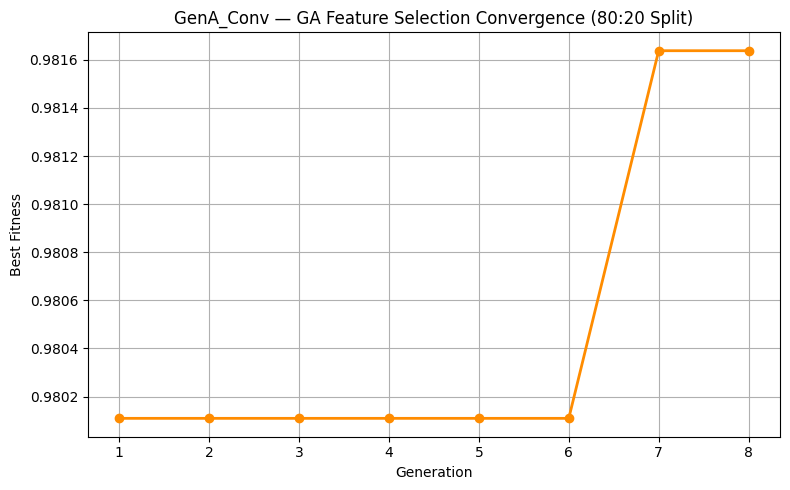

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(ga_history)+1), ga_history, marker="o", color='darkorange', linewidth=2)
plt.xlabel("Generation"); plt.ylabel("Best Fitness")
plt.title("GenA_Conv — GA Feature Selection Convergence (80:20 Split)")
plt.grid(True); plt.tight_layout(); plt.show()

## GreyW_Conv — Grey Wolf Optimizer Feature Selection

### Algorithm Overview
**Grey Wolf Optimizer (GWO)** simulates the social leadership and hunting behaviour of grey wolf packs. The population is ranked as:

| Rank | Role | Description |
|------|------|-------------|
| α (Alpha) | Best solution | Leads the hunt — all wolves move toward it |
| β (Beta) | 2nd best | Assists the alpha in decision making |
| δ (Delta) | 3rd best | Obeys alpha/beta; guides omega wolves |
| ω (Omega) | Remaining | Follow α, β, δ — explore the search space |

**Update equations:**

Each wolf updates its continuous position using the influence of α, β, δ:

```
A = 2·a·r₁ − a       (a decreases linearly from 2 → 0)
C = 2·r₂
D_leader = |C · X_leader − X_wolf|
X_new_from_leader = X_leader − A · D_leader
X_wolf ← (X_from_α + X_from_β + X_from_δ) / 3
```

**Binarisation:** continuous positions ∈ [0, 1] are thresholded at 0.5 to obtain the feature mask.

**Hyperparameters used:** num_wolves = 12, max_iter = 8, a_start = 2.0

In [25]:
def cnn_gwo_feature_selection(
    X_train, y_train, X_val, y_val,
    num_features,
    num_wolves=12,
    max_iter=8,
    a_start=2.0
):
    """
    GreyW_Conv: Grey Wolf Optimizer wrapper feature selection over CNN features.

    Parameters
    ----------
    num_wolves : int   – pack size (search agents)
    max_iter   : int   – number of hunting (iteration) cycles
    a_start    : float – initial value of 'a' (decreases to 0 over iterations)
    """
    # ── Initialisation ──────────────────────────────────────────────────────
    # Continuous positions in [0, 1] for smooth GWO update equations
    cont_pos = np.random.uniform(0, 1, size=(num_wolves, num_features))

    def to_mask(pos):
        mask = (pos >= 0.5).astype(int)
        if np.sum(mask) == 0:
            mask[np.argmax(pos)] = 1
        return mask

    def get_fitness(pos):
        return evaluate_feature_mask(to_mask(pos), X_train, y_train, X_val, y_val)

    # ── Evaluate initial pack ───────────────────────────────────────────────
    fitness_scores = np.array([get_fitness(cont_pos[i]) for i in range(num_wolves)])

    # Sort → assign α, β, δ
    sorted_idx = np.argsort(fitness_scores)[::-1]
    alpha_pos, alpha_score = cont_pos[sorted_idx[0]].copy(), fitness_scores[sorted_idx[0]]
    beta_pos,  beta_score  = cont_pos[sorted_idx[1]].copy(), fitness_scores[sorted_idx[1]]
    delta_pos, delta_score = cont_pos[sorted_idx[2]].copy(), fitness_scores[sorted_idx[2]]

    fitness_history = [alpha_score]

    for iteration in range(max_iter):
        # ── Linearly decrease 'a' from a_start → 0 ─────────────────────────
        a = a_start * (1 - iteration / max_iter)

        # ── Update each wolf's position ─────────────────────────────────────
        for i in range(num_wolves):
            X_new = np.zeros(num_features)
            for leader_pos in [alpha_pos, beta_pos, delta_pos]:
                r1 = np.random.rand(num_features)
                r2 = np.random.rand(num_features)
                A  = 2 * a * r1 - a           # coefficient vector A
                C  = 2 * r2                    # coefficient vector C
                D  = np.abs(C * leader_pos - cont_pos[i])   # distance to leader
                X_new += leader_pos - A * D    # step toward leader

            cont_pos[i] = np.clip(X_new / 3.0, 0, 1)  # average of 3 influences

        # ── Re-evaluate fitness & update α, β, δ ───────────────────────────
        for i in range(num_wolves):
            fitness = get_fitness(cont_pos[i])
            if fitness > alpha_score:
                delta_pos, delta_score = beta_pos.copy(),  beta_score
                beta_pos,  beta_score  = alpha_pos.copy(), alpha_score
                alpha_pos, alpha_score = cont_pos[i].copy(), fitness
            elif fitness > beta_score:
                delta_pos, delta_score = beta_pos.copy(), beta_score
                beta_pos,  beta_score  = cont_pos[i].copy(), fitness
            elif fitness > delta_score:
                delta_pos, delta_score = cont_pos[i].copy(), fitness

        fitness_history.append(alpha_score)
        best_mask_now = to_mask(alpha_pos)
        print(f"Iteration {iteration+1:2d}/{max_iter} | "
              f"Best Fitness: {alpha_score:.4f} | "
              f"a: {a:.3f} | "
              f"Selected Features: {np.sum(best_mask_now)}")

    best_mask = to_mask(alpha_pos)
    return best_mask, fitness_history

print("GreyW_Conv (GWO) function defined")

GreyW_Conv (GWO) function defined


In [26]:
# ── Run GreyW_Conv on 80:20 split ─────────────────────────────────────────
print(f"Running GreyW_Conv on {num_features} CNN features (80:20 split)...\n")

t0_gwo = time.time()
gwo_best_mask, gwo_history = cnn_gwo_feature_selection(
    X_fs_train_small, y_fs_train_small,
    X_fs_val_small, y_fs_val_small,
    num_features=num_features,
    num_wolves=12, max_iter=8, a_start=2.0
)
gwo_time_8020 = time.time() - t0_gwo

gwo_selected_features = np.where(gwo_best_mask == 1)[0]
print(f"\nGreyW_Conv selected {len(gwo_selected_features)} features in {gwo_time_8020:.1f}s")
print("Selected indices:", gwo_selected_features)

Running GreyW_Conv on 128 CNN features (80:20 split)...

Iteration  1/8 | Best Fitness: 0.9808 | a: 2.000 | Selected Features: 66
Iteration  2/8 | Best Fitness: 0.9808 | a: 1.750 | Selected Features: 66
Iteration  3/8 | Best Fitness: 0.9808 | a: 1.500 | Selected Features: 66
Iteration  4/8 | Best Fitness: 0.9808 | a: 1.250 | Selected Features: 64
Iteration  5/8 | Best Fitness: 0.9808 | a: 1.000 | Selected Features: 64
Iteration  6/8 | Best Fitness: 0.9814 | a: 0.750 | Selected Features: 66
Iteration  7/8 | Best Fitness: 0.9816 | a: 0.500 | Selected Features: 62
Iteration  8/8 | Best Fitness: 0.9822 | a: 0.250 | Selected Features: 63

GreyW_Conv selected 63 features in 47.5s
Selected indices: [  1   3   5   7   9  10  11  13  17  18  20  21  22  23  27  29  32  33
  34  35  38  40  43  48  49  50  52  53  56  57  58  59  61  63  65  67
  70  73  75  79  80  82  84  85  89  91  93  95  98  99 100 102 104 106
 107 108 110 111 114 120 121 122 127]


In [27]:
# ── Evaluate GreyW_Conv ───────────────────────────────────────────────────
greyw_model = LogisticRegression(max_iter=1000, solver="lbfgs", n_jobs=-1)
greyw_model.fit(X_train_features_scaled[:, gwo_selected_features], y_train_features)
greyw_preds = greyw_model.predict(X_test_features_scaled[:, gwo_selected_features])

greyw_acc  = accuracy_score(y_test_features, greyw_preds)
greyw_prec = precision_score(y_test_features, greyw_preds, average="weighted", zero_division=0)
greyw_rec  = recall_score(y_test_features, greyw_preds, average="weighted", zero_division=0)
greyw_f1   = f1_score(y_test_features, greyw_preds, average="weighted", zero_division=0)

print("Method: GreyW_Conv (GWO)")
print(f"Selected Features: {len(gwo_selected_features)}")
print(f"Accuracy : {greyw_acc:.4f}")
print(f"Precision: {greyw_prec:.4f}")
print(f"Recall   : {greyw_rec:.4f}")
print(f"F1-score : {greyw_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_features, greyw_preds, zero_division=0))

Method: GreyW_Conv (GWO)
Selected Features: 63
Accuracy : 0.9840
Precision: 0.9840
Recall   : 0.9840
F1-score : 0.9840

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1381
           1       0.99      0.99      0.99      1575
           2       0.98      0.98      0.98      1398
           3       0.98      0.99      0.99      1428
           4       0.99      0.98      0.98      1365
           5       0.99      0.98      0.99      1263
           6       0.99      0.99      0.99      1375
           7       0.98      0.98      0.98      1459
           8       0.98      0.98      0.98      1365
           9       0.98      0.98      0.98      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



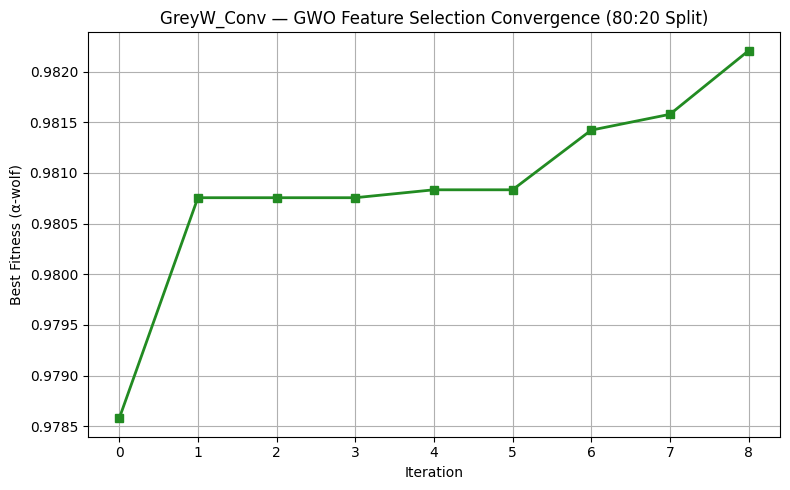

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(range(len(gwo_history)), gwo_history, marker="s", color='forestgreen', linewidth=2)
plt.xlabel("Iteration"); plt.ylabel("Best Fitness (α-wolf)")
plt.title("GreyW_Conv — GWO Feature Selection Convergence (80:20 Split)")
plt.grid(True); plt.tight_layout(); plt.show()

## ParticleS_Conv — Particle Swarm Optimization Feature Selection

### Algorithm Overview
**PSO** models a flock of particles flying through the feature space. Each particle remembers its personal best position and is attracted toward the swarm's global best.

| Component | Symbol | Role |
|-----------|--------|------|
| Inertia weight | w | Controls how much the particle keeps its current direction |
| Cognitive coefficient | c₁ | Pulls particle toward its own personal best (pbest) |
| Social coefficient | c₂ | Pulls particle toward the swarm's global best (gbest) |

**Velocity & position update equations:**

```
v_i ← w·v_i + c₁·r₁·(pbest_i − x_i) + c₂·r₂·(gbest − x_i)
x_i ← x_i + v_i          (clipped to [0,1])
```

**Binarisation:** sigmoid transfer function + stochastic threshold:
```
S(v) = 1 / (1 + exp(−v))
x_binary[j] = 1  if S(x[j]) > U(0,1)  else 0
```

**Hyperparameters used:** swarm_size = 12, max_iter = 8, w = 0.7, c₁ = 1.5, c₂ = 1.5, v_max = 4.0

In [29]:
def cnn_pso_feature_selection(
    X_train, y_train, X_val, y_val,
    num_features,
    swarm_size=12,
    max_iter=8,
    w=0.7,      # inertia weight
    c1=1.5,     # cognitive coefficient
    c2=1.5,     # social coefficient
    v_max=4.0   # velocity clamp
):
    """
    ParticleS_Conv: Particle Swarm Optimization wrapper feature selection.

    Parameters
    ----------
    swarm_size : int   – number of particles
    max_iter   : int   – number of iteration steps
    w          : float – inertia weight (momentum)
    c1         : float – cognitive (personal best) attraction
    c2         : float – social (global best) attraction
    v_max      : float – maximum velocity magnitude
    """
    # ── Sigmoid binarisation ────────────────────────────────────────────────
    def sigmoid(v):
        return 1.0 / (1.0 + np.exp(-np.clip(v, -500, 500)))

    def to_mask(pos):
        s = sigmoid(pos)
        mask = (s > np.random.uniform(0, 1, size=pos.shape)).astype(int)
        if np.sum(mask) == 0:
            mask[np.argmax(s)] = 1
        return mask

    def get_fitness(pos):
        return evaluate_feature_mask(to_mask(pos), X_train, y_train, X_val, y_val)

    # ── Initialisation ──────────────────────────────────────────────────────
    positions  = np.random.uniform(0, 1, size=(swarm_size, num_features))
    velocities = np.random.uniform(-1, 1, size=(swarm_size, num_features))

    # Personal bests
    pbest_pos     = positions.copy()
    pbest_fitness = np.array([get_fitness(positions[i]) for i in range(swarm_size)])

    # Global best
    gbest_idx      = np.argmax(pbest_fitness)
    gbest_pos      = pbest_pos[gbest_idx].copy()
    gbest_fitness  = pbest_fitness[gbest_idx]

    fitness_history = [gbest_fitness]

    for iteration in range(max_iter):
        for i in range(swarm_size):
            r1 = np.random.uniform(0, 1, num_features)
            r2 = np.random.uniform(0, 1, num_features)

            # ── Velocity update ─────────────────────────────────────────────
            velocities[i] = (
                w  * velocities[i]
                + c1 * r1 * (pbest_pos[i] - positions[i])
                + c2 * r2 * (gbest_pos    - positions[i])
            )
            velocities[i] = np.clip(velocities[i], -v_max, v_max)

            # ── Position update ─────────────────────────────────────────────
            positions[i] = np.clip(positions[i] + velocities[i], 0, 1)

            # ── Evaluate ────────────────────────────────────────────────────
            fitness = get_fitness(positions[i])

            # Update personal best
            if fitness > pbest_fitness[i]:
                pbest_fitness[i] = fitness
                pbest_pos[i] = positions[i].copy()

            # Update global best
            if fitness > gbest_fitness:
                gbest_fitness = fitness
                gbest_pos = positions[i].copy()

        fitness_history.append(gbest_fitness)
        best_mask_now = to_mask(gbest_pos)
        print(f"Iteration {iteration+1:2d}/{max_iter} | "
              f"gbest Fitness: {gbest_fitness:.4f} | "
              f"Selected Features: {np.sum(best_mask_now)}")

    best_mask = to_mask(gbest_pos)
    return best_mask, fitness_history

print("ParticleS_Conv (PSO) function defined")

ParticleS_Conv (PSO) function defined


In [30]:
# ── Run ParticleS_Conv on 80:20 split ────────────────────────────────────
print(f"Running ParticleS_Conv on {num_features} CNN features (80:20 split)...\n")

t0_pso = time.time()
pso_best_mask, pso_history = cnn_pso_feature_selection(
    X_fs_train_small, y_fs_train_small,
    X_fs_val_small, y_fs_val_small,
    num_features=num_features,
    swarm_size=12, max_iter=8,
    w=0.7, c1=1.5, c2=1.5, v_max=4.0
)
pso_time_8020 = time.time() - t0_pso

pso_selected_features = np.where(pso_best_mask == 1)[0]
print(f"\nParticleS_Conv selected {len(pso_selected_features)} features in {pso_time_8020:.1f}s")
print("Selected indices:", pso_selected_features)

Running ParticleS_Conv on 128 CNN features (80:20 split)...

Iteration  1/8 | gbest Fitness: 0.9788 | Selected Features: 78
Iteration  2/8 | gbest Fitness: 0.9802 | Selected Features: 89
Iteration  3/8 | gbest Fitness: 0.9802 | Selected Features: 81
Iteration  4/8 | gbest Fitness: 0.9802 | Selected Features: 80
Iteration  5/8 | gbest Fitness: 0.9802 | Selected Features: 79
Iteration  6/8 | gbest Fitness: 0.9802 | Selected Features: 86
Iteration  7/8 | gbest Fitness: 0.9802 | Selected Features: 86
Iteration  8/8 | gbest Fitness: 0.9802 | Selected Features: 78

ParticleS_Conv selected 83 features in 55.7s
Selected indices: [  0   1   3   5   7  10  11  12  14  16  17  18  19  20  22  23  24  27
  28  29  31  34  35  36  37  38  39  40  42  43  44  45  46  47  48  50
  53  55  56  57  59  60  63  66  70  71  72  73  74  75  77  78  79  80
  81  82  83  84  86  89  90  92  96  97  98  99 102 103 105 106 107 108
 111 112 113 115 116 117 119 123 124 125 126]


In [31]:
# ── Evaluate ParticleS_Conv ───────────────────────────────────────────────
particles_model = LogisticRegression(max_iter=1000, solver="lbfgs", n_jobs=-1)
particles_model.fit(X_train_features_scaled[:, pso_selected_features], y_train_features)
particles_preds = particles_model.predict(X_test_features_scaled[:, pso_selected_features])

particles_acc  = accuracy_score(y_test_features, particles_preds)
particles_prec = precision_score(y_test_features, particles_preds, average="weighted", zero_division=0)
particles_rec  = recall_score(y_test_features, particles_preds, average="weighted", zero_division=0)
particles_f1   = f1_score(y_test_features, particles_preds, average="weighted", zero_division=0)

print("Method: ParticleS_Conv (PSO)")
print(f"Selected Features: {len(pso_selected_features)}")
print(f"Accuracy : {particles_acc:.4f}")
print(f"Precision: {particles_prec:.4f}")
print(f"Recall   : {particles_rec:.4f}")
print(f"F1-score : {particles_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_features, particles_preds, zero_division=0))

Method: ParticleS_Conv (PSO)
Selected Features: 83
Accuracy : 0.9849
Precision: 0.9849
Recall   : 0.9849
F1-score : 0.9849

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1381
           1       0.99      0.99      0.99      1575
           2       0.98      0.98      0.98      1398
           3       0.99      0.99      0.99      1428
           4       0.98      0.98      0.98      1365
           5       0.99      0.99      0.99      1263
           6       0.99      0.98      0.99      1375
           7       0.98      0.98      0.98      1459
           8       0.98      0.98      0.98      1365
           9       0.98      0.98      0.98      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



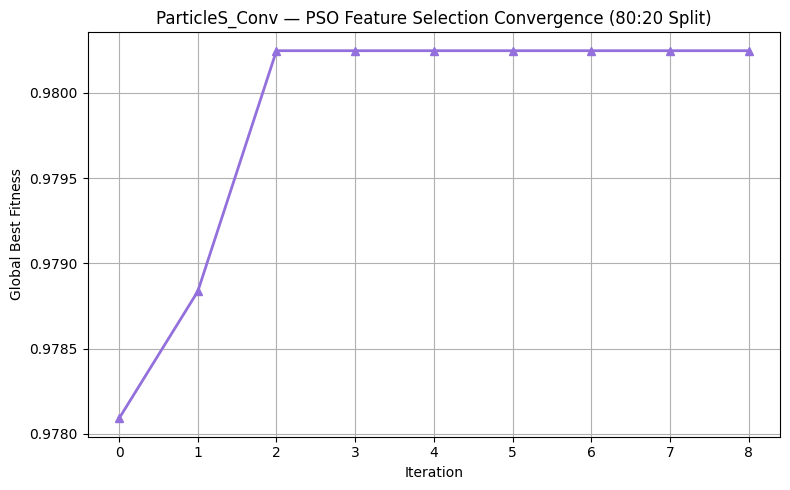

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(range(len(pso_history)), pso_history, marker="^", color='mediumpurple', linewidth=2)
plt.xlabel("Iteration"); plt.ylabel("Global Best Fitness")
plt.title("ParticleS_Conv — PSO Feature Selection Convergence (80:20 Split)")
plt.grid(True); plt.tight_layout(); plt.show()

## Multi-Split Comparison — All 5 Splits × All 4 Methods

In [33]:
def run_all_methods_for_one_split(train_ratio, test_ratio):
    """
    For a given train/test ratio, runs:
      1. Federated CNN training (3 rounds)
      2. Conv_NN  — LogReg on all 128 CNN features
      3. GenA_Conv — GA feature selection
      4. GreyW_Conv — GWO feature selection
      5. ParticleS_Conv — PSO feature selection
    Returns a list of result dicts and timing dict.
    """
    split_name = f"{int(train_ratio*100)}:{int(test_ratio*100)}"
    print(f"\n{'='*60}")
    print(f"  SPLIT {split_name}")
    print(f"{'='*60}")

    results = []
    timing  = {}

    # 1. Train-test split & reshape
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=test_ratio, random_state=42, stratify=y)
    X_tr_cnn = X_tr.reshape(-1, 1, 28, 28)
    X_te_cnn = X_te.reshape(-1, 1, 28, 28)

    # 2. Federated CNN (3 rounds)
    X_tr_fl, X_val_c, y_tr_fl, y_val_c = train_test_split(
        X_tr_cnn, y_tr, test_size=0.15, random_state=42, stratify=y_tr)
    clients_s  = create_federated_clients(X_tr_fl, y_tr_fl, num_clients=5)
    agent_s    = ClientSelectorQAgent(num_clients=5)
    global_m   = FedCNN().to(device)

    for rnd in range(3):
        sel_idx = agent_s.select_clients(k=3)
        cm_list, rwd = [], []
        for idx in sel_idx:
            cm = copy.deepcopy(global_m).to(device)
            cm = train_one_client(cm, clients_s[idx], epochs=1)
            v_acc, *_ = evaluate_cnn_model(cm, X_val_c[:3000], y_val_c[:3000])
            rwd.append(v_acc); cm_list.append(cm)
        global_m = federated_average(global_m, cm_list)
        agent_s.update(sel_idx, rwd)

    # 3. Extract & scale features
    X_tr_feat, y_tr_feat = extract_cnn_features(global_m, X_tr_cnn, y_tr)
    X_te_feat, y_te_feat = extract_cnn_features(global_m, X_te_cnn, y_te)
    scaler = StandardScaler()
    X_tr_feat_sc = scaler.fit_transform(X_tr_feat)
    X_te_feat_sc = scaler.transform(X_te_feat)

    # ── Conv_NN ──────────────────────────────────────────────────────────────
    t0 = time.time()
    m = LogisticRegression(max_iter=1000, solver="lbfgs", n_jobs=-1)
    m.fit(X_tr_feat_sc, y_tr_feat)
    preds = m.predict(X_te_feat_sc)
    timing["Conv_NN"] = time.time() - t0
    results.append({
        "Split": split_name, "Method": "Conv_NN",
        "Selected Features": 128,
        "Accuracy":  accuracy_score(y_te_feat, preds),
        "Precision": precision_score(y_te_feat, preds, average="weighted", zero_division=0),
        "Recall":    recall_score(y_te_feat, preds, average="weighted", zero_division=0),
        "F1-score":  f1_score(y_te_feat, preds, average="weighted", zero_division=0)
    })

    # ── Prepare small FS subsets ──────────────────────────────────────────
    X_fs_tr, X_fs_v, y_fs_tr, y_fs_v = train_test_split(
        X_tr_feat_sc, y_tr_feat, test_size=0.20, random_state=42, stratify=y_tr_feat)
    Xt = X_fs_tr[:6000]; Xv = X_fs_v[:2000]
    yt = y_fs_tr[:6000]; yv = y_fs_v[:2000]
    nf = X_tr_feat_sc.shape[1]

    def record(method_name, mask, t_elapsed):
        sel = np.where(mask == 1)[0]
        timing[method_name] = t_elapsed
        m2 = LogisticRegression(max_iter=1000, solver="lbfgs", n_jobs=-1)
        m2.fit(X_tr_feat_sc[:, sel], y_tr_feat)
        pr = m2.predict(X_te_feat_sc[:, sel])
        results.append({
            "Split": split_name, "Method": method_name,
            "Selected Features": len(sel),
            "Accuracy":  accuracy_score(y_te_feat, pr),
            "Precision": precision_score(y_te_feat, pr, average="weighted", zero_division=0),
            "Recall":    recall_score(y_te_feat, pr, average="weighted", zero_division=0),
            "F1-score":  f1_score(y_te_feat, pr, average="weighted", zero_division=0)
        })
        return sel

    # ── GenA_Conv ────────────────────────────────────────────────────────────
    print(f"  [GenA_Conv] GA running...")
    t0 = time.time()
    mask_ga, _ = cnn_ga_feature_selection(
        Xt, yt, Xv, yv, nf, population_size=8, generations=5, mutation_rate=0.05)
    sel_ga = record("GenA_Conv", mask_ga, time.time() - t0)
    print(f"  GenA_Conv done — {len(sel_ga)} features")

    # ── GreyW_Conv ───────────────────────────────────────────────────────────
    print(f"  [GreyW_Conv] GWO running...")
    t0 = time.time()
    mask_gwo, _ = cnn_gwo_feature_selection(
        Xt, yt, Xv, yv, nf, num_wolves=8, max_iter=5, a_start=2.0)
    sel_gwo = record("GreyW_Conv", mask_gwo, time.time() - t0)
    print(f"  GreyW_Conv done — {len(sel_gwo)} features")

    # ── ParticleS_Conv ───────────────────────────────────────────────────────
    print(f"  [ParticleS_Conv] PSO running...")
    t0 = time.time()
    mask_pso, _ = cnn_pso_feature_selection(
        Xt, yt, Xv, yv, nf, swarm_size=8, max_iter=5, w=0.7, c1=1.5, c2=1.5)
    sel_pso = record("ParticleS_Conv", mask_pso, time.time() - t0)
    print(f"  ParticleS_Conv done — {len(sel_pso)} features")

    for r in results:
        print(f"  {r['Method']:20s} Acc={r['Accuracy']:.4f}  F1={r['F1-score']:.4f}  Feats={r['Selected Features']}")

    return results, timing

print("Multi-split runner defined")

Multi-split runner defined


In [34]:
# ── Run all splits ────────────────────────────────────────────────────────
all_split_results = []
all_split_timing  = {}

for train_ratio, test_ratio in splits:
    split_name = f"{int(train_ratio*100)}:{int(test_ratio*100)}"
    res, tim = run_all_methods_for_one_split(train_ratio, test_ratio)
    all_split_results.extend(res)
    all_split_timing[split_name] = tim

final_df = pd.DataFrame(all_split_results)
print("\nAll splits complete!")
final_df


  SPLIT 65:35
Client 1: 7735 samples
Client 2: 7735 samples
Client 3: 7735 samples
Client 4: 7735 samples
Client 5: 7735 samples
  [GenA_Conv] GA running...
Generation  1/5 | Best Fitness: 0.9794 | Selected Features: 66
Generation  2/5 | Best Fitness: 0.9794 | Selected Features: 66
Generation  3/5 | Best Fitness: 0.9794 | Selected Features: 66
Generation  4/5 | Best Fitness: 0.9809 | Selected Features: 67
Generation  5/5 | Best Fitness: 0.9809 | Selected Features: 67
  GenA_Conv done — 67 features
  [GreyW_Conv] GWO running...
Iteration  1/5 | Best Fitness: 0.9798 | a: 2.000 | Selected Features: 70
Iteration  2/5 | Best Fitness: 0.9798 | a: 1.600 | Selected Features: 70
Iteration  3/5 | Best Fitness: 0.9815 | a: 1.200 | Selected Features: 63
Iteration  4/5 | Best Fitness: 0.9815 | a: 0.800 | Selected Features: 63
Iteration  5/5 | Best Fitness: 0.9815 | a: 0.400 | Selected Features: 63
  GreyW_Conv done — 63 features
  [ParticleS_Conv] PSO running...
Iteration  1/5 | gbest Fitness: 0.9

,Split,Method,Selected Features,Accuracy,Precision,Recall,F1-score
0,65:35,Conv_NN,128,0.981837,0.981839,0.981837,0.981833
1,65:35,GenA_Conv,67,0.979388,0.979390,0.979388,0.979382
2,65:35,GreyW_Conv,63,0.978367,0.978369,0.978367,0.978362
3,65:35,ParticleS_Conv,85,0.981306,0.981306,0.981306,0.981298
4,70:30,Conv_NN,128,0.983286,0.983288,0.983286,0.983283
5,70:30,GenA_Conv,71,0.980952,0.980952,0.980952,0.980945
6,70:30,GreyW_Conv,49,0.979095,0.979085,0.979095,0.979085
7,70:30,ParticleS_Conv,76,0.980952,0.980949,0.980952,0.980944
8,75:25,Conv_NN,128,0.984057,0.984056,0.984057,0.984054
9,75:25,GenA_Conv,75,0.981943,0.981941,0.981943,0.981939


In [35]:
# ── Save final_df for reference ───────────────────────────────────────────
final_df.to_csv("all_methods_results.csv", index=False)
print("Results saved to all_methods_results.csv")

Results saved to all_methods_results.csv


## Computational Complexity Analysis

All four methods are compared on:
1. **Theoretical complexity** — big-O characterisation
2. **Measured wall-clock time** — actual seconds taken per algorithm across splits

In [36]:
# ── 10.1 Theoretical Complexity Table ────────────────────────────────────
complexity_data = {
    "Method": ["Conv_NN", "GenA_Conv", "GreyW_Conv", "ParticleS_Conv"],
    "Category": ["CNN + Classifier", "Evolutionary", "Swarm (social hierarchy)", "Swarm (velocity-based)"],
    "Complexity": [
        "O(R·K·E·n·C + n·m)",
        "O(G·P·n·m)",
        "O(I·N·n·m)",
        "O(I·S·n·m)"
    ],
    "Key Parameters": [
        "R=rounds, K=clients, E=epochs, n=features, m=samples, C=CNN ops",
        "G=generations, P=population, n=features, m=samples",
        "I=iterations, N=wolves, n=features, m=samples",
        "I=iterations, S=swarm size, n=features, m=samples"
    ],
    "Gradient-based?": ["Yes (CNN backprop)", "No", "No", "No"],
    "Memory": ["O(CNN params + n·m)", "O(P·n)", "O(N·n)", "O(S·n)"],
    "Convergence": ["Smooth (gradient descent)", "Population diversity", "Leader convergence", "Swarm consensus"],
    "Feature Interactions": ["Learned (deep conv filters)", "Crossover + mutation", "Leader-guided update", "pbest + gbest"]
}

complexity_df = pd.DataFrame(complexity_data)
print("Theoretical Complexity Summary")
complexity_df

Theoretical Complexity Summary


,Method,Category,Complexity,Key Parameters,Gradient-based?,Memory,Convergence,Feature Interactions
0,Conv_NN,CNN + Classifier,O(R·K·E·n·C + n·m),"R=rounds, K=clients, E=epochs, n=features, m=s...",Yes (CNN backprop),O(CNN params + n·m),Smooth (gradient descent),Learned (deep conv filters)
1,GenA_Conv,Evolutionary,O(G·P·n·m),"G=generations, P=population, n=features, m=sam...",No,O(P·n),Population diversity,Crossover + mutation
2,GreyW_Conv,Swarm (social hierarchy),O(I·N·n·m),"I=iterations, N=wolves, n=features, m=samples",No,O(N·n),Leader convergence,Leader-guided update
3,ParticleS_Conv,Swarm (velocity-based),O(I·S·n·m),"I=iterations, S=swarm size, n=features, m=samples",No,O(S·n),Swarm consensus,pbest + gbest


In [37]:
# ── 10.2 Measured time per algorithm ─────────────────────────────────────
timing_rows = []
for split_name, tim_dict in all_split_timing.items():
    for method, elapsed in tim_dict.items():
        timing_rows.append({"Split": split_name, "Method": method, "Time (s)": elapsed})

timing_df = pd.DataFrame(timing_rows)

# Mean time across splits
mean_timing = timing_df.groupby("Method")["Time (s)"].mean().reset_index()
mean_timing.columns = ["Method", "Mean Time (s)"]
mean_timing = mean_timing.sort_values("Mean Time (s)")
print("Mean measured time (seconds) per algorithm across all 5 splits:")
print(mean_timing.to_string(index=False))

Mean measured time (seconds) per algorithm across all 5 splits:
        Method  Mean Time (s)
       Conv_NN       6.905219
     GenA_Conv      13.800104
    GreyW_Conv      15.865832
ParticleS_Conv      19.027633


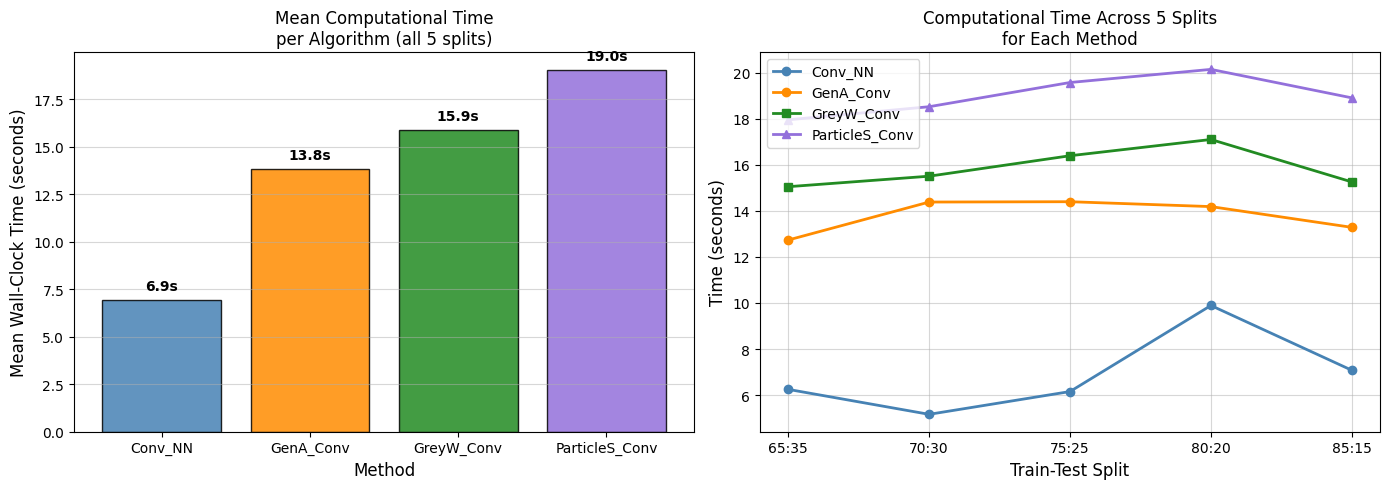

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {"Conv_NN": "steelblue", "GenA_Conv": "darkorange",
          "GreyW_Conv": "forestgreen", "ParticleS_Conv": "mediumpurple"}

# ── Left: Mean time bar chart ─────────────────────────────────────────────
methods_ordered = mean_timing["Method"].tolist()
times_ordered   = mean_timing["Mean Time (s)"].tolist()
bar_colors = [colors[m] for m in methods_ordered]
bars = axes[0].bar(methods_ordered, times_ordered, color=bar_colors, edgecolor='black', alpha=0.85)
axes[0].set_xlabel("Method", fontsize=12)
axes[0].set_ylabel("Mean Wall-Clock Time (seconds)", fontsize=12)
axes[0].set_title("Mean Computational Time\nper Algorithm (all 5 splits)", fontsize=12)
axes[0].grid(axis='y', alpha=0.5)
for bar, t in zip(bars, times_ordered):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02*max(times_ordered),
                 f"{t:.1f}s", ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Right: Time across splits (line chart) ────────────────────────────────
split_labels = [f"{int(tr*100)}:{int(te*100)}" for tr, te in splits]
for method in ["Conv_NN", "GenA_Conv", "GreyW_Conv", "ParticleS_Conv"]:
    times = []
    for sp in split_labels:
        t = all_split_timing.get(sp, {}).get(method, np.nan)
        times.append(t)
    marker = {'Conv_NN':'o','GenA_Conv':'o','GreyW_Conv':'s','ParticleS_Conv':'^'}[method]
    axes[1].plot(split_labels, times, marker=marker, label=method,
                 color=colors[method], linewidth=2)

axes[1].set_xlabel("Train-Test Split", fontsize=12)
axes[1].set_ylabel("Time (seconds)", fontsize=12)
axes[1].set_title("Computational Time Across 5 Splits\nfor Each Method", fontsize=12)
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.5)

plt.tight_layout(); plt.show()

In [39]:
# ── 10.3 Fitness iterations/generations evaluated table ───────────────────
iter_data = {
    "Method": ["GenA_Conv", "GreyW_Conv", "ParticleS_Conv"],
    "Population / Swarm Size": [8, 8, 8],
    "Generations / Iterations": [5, 5, 5],
    "Fitness Evaluations (total)": [8*5, 8*5, 8*5],  # pop * gens
    "Exploration Strategy": ["Crossover + Mutation", "Leader-guided hunting", "Inertia + pbest + gbest"],
    "Exploitation Strategy": ["Elitist selection", "α, β, δ guidance", "pbest memory"]
}
iter_df = pd.DataFrame(iter_data)
print("Algorithm Iteration Budget (multi-split runs):")
iter_df

Algorithm Iteration Budget (multi-split runs):


,Method,Population / Swarm Size,Generations / Iterations,Fitness Evaluations (total),Exploration Strategy,Exploitation Strategy
0,GenA_Conv,8,5,40,Crossover + Mutation,Elitist selection
1,GreyW_Conv,8,5,40,Leader-guided hunting,"α, β, δ guidance"
2,ParticleS_Conv,8,5,40,Inertia + pbest + gbest,pbest memory


## Single-Split Comparison (80:20) — All 4 Methods

In [40]:
# Build 80:20 single-split comparison from final_df
df_8020 = final_df[final_df["Split"] == "80:20"].copy()

# Fallback: use the already-computed 80:20 results
if len(df_8020) == 0:
    df_8020 = pd.DataFrame([
        {"Split":"80:20","Method":"Conv_NN","Selected Features":128,
         "Accuracy":conv_nn_acc,"Precision":conv_nn_prec,"Recall":conv_nn_rec,"F1-score":conv_nn_f1},
        {"Split":"80:20","Method":"GenA_Conv","Selected Features":len(ga_selected_features),
         "Accuracy":gena_acc,"Precision":gena_prec,"Recall":gena_rec,"F1-score":gena_f1},
        {"Split":"80:20","Method":"GreyW_Conv","Selected Features":len(gwo_selected_features),
         "Accuracy":greyw_acc,"Precision":greyw_prec,"Recall":greyw_rec,"F1-score":greyw_f1},
        {"Split":"80:20","Method":"ParticleS_Conv","Selected Features":len(pso_selected_features),
         "Accuracy":particles_acc,"Precision":particles_prec,"Recall":particles_rec,"F1-score":particles_f1},
    ])

print("80:20 Comparison Table:")
df_8020[["Method","Selected Features","Accuracy","Precision","Recall","F1-score"]]

80:20 Comparison Table:


,Method,Selected Features,Accuracy,Precision,Recall,F1-score
12,Conv_NN,128,0.983357,0.983350,0.983357,0.983347
13,GenA_Conv,63,0.979500,0.979486,0.979500,0.979485
14,GreyW_Conv,78,0.981929,0.981925,0.981929,0.981922
15,ParticleS_Conv,78,0.982286,0.982284,0.982286,0.982276


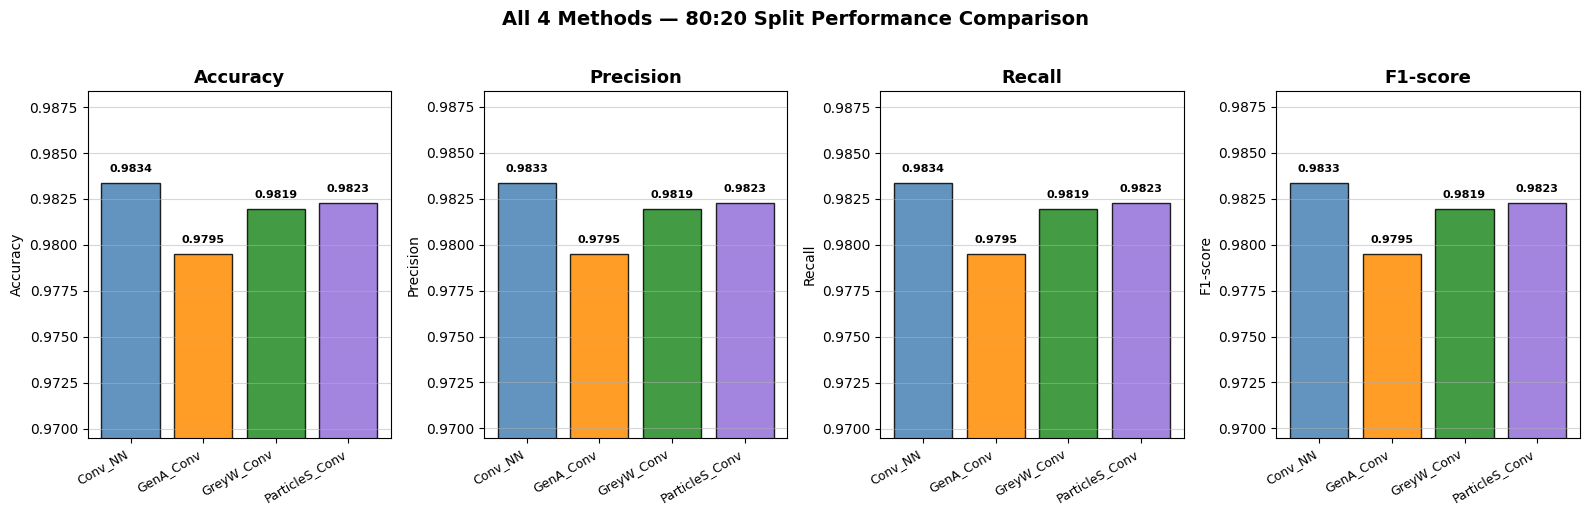

In [41]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
method_order = ["Conv_NN", "GenA_Conv", "GreyW_Conv", "ParticleS_Conv"]
bar_colors = ["steelblue", "darkorange", "forestgreen", "mediumpurple"]

for ax, metric in zip(axes, metrics):
    vals = [df_8020[df_8020["Method"]==m][metric].values[0]
            if len(df_8020[df_8020["Method"]==m]) > 0 else 0
            for m in method_order]
    bars = ax.bar(method_order, vals, color=bar_colors, edgecolor='black', alpha=0.85)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric); ax.set_xticklabels(method_order, rotation=30, ha='right', fontsize=9)
    min_v = max(0, min(vals) - 0.01)
    max_v = min(1.0, max(vals) + 0.005)
    ax.set_ylim(min_v, max_v)
    ax.grid(axis='y', alpha=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
                f"{v:.4f}", ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle("All 4 Methods — 80:20 Split Performance Comparison", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

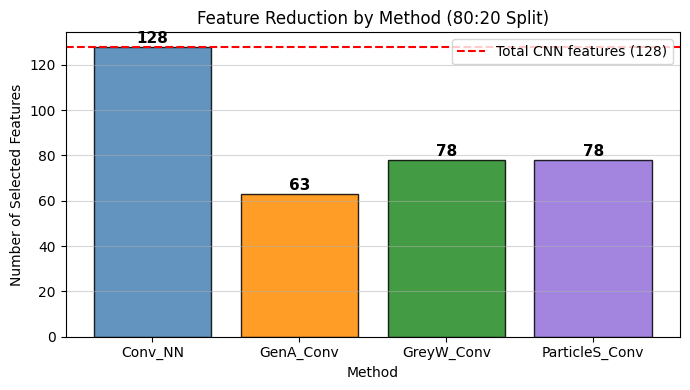

In [42]:
# ── Selected Features Comparison ─────────────────────────────────────────
plt.figure(figsize=(7, 4))
feats = [df_8020[df_8020["Method"]==m]["Selected Features"].values[0]
         if len(df_8020[df_8020["Method"]==m]) > 0 else 0
         for m in method_order]
bars = plt.bar(method_order, feats, color=bar_colors, edgecolor='black', alpha=0.85)
plt.axhline(128, color='red', linestyle='--', linewidth=1.5, label='Total CNN features (128)')
plt.xlabel("Method"); plt.ylabel("Number of Selected Features")
plt.title("Feature Reduction by Method (80:20 Split)")
plt.legend(); plt.grid(axis='y', alpha=0.5)
for bar, f in zip(bars, feats):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             str(f), ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

## Multi-Split Comparison Graphs — All 5 Splits × All 4 Methods

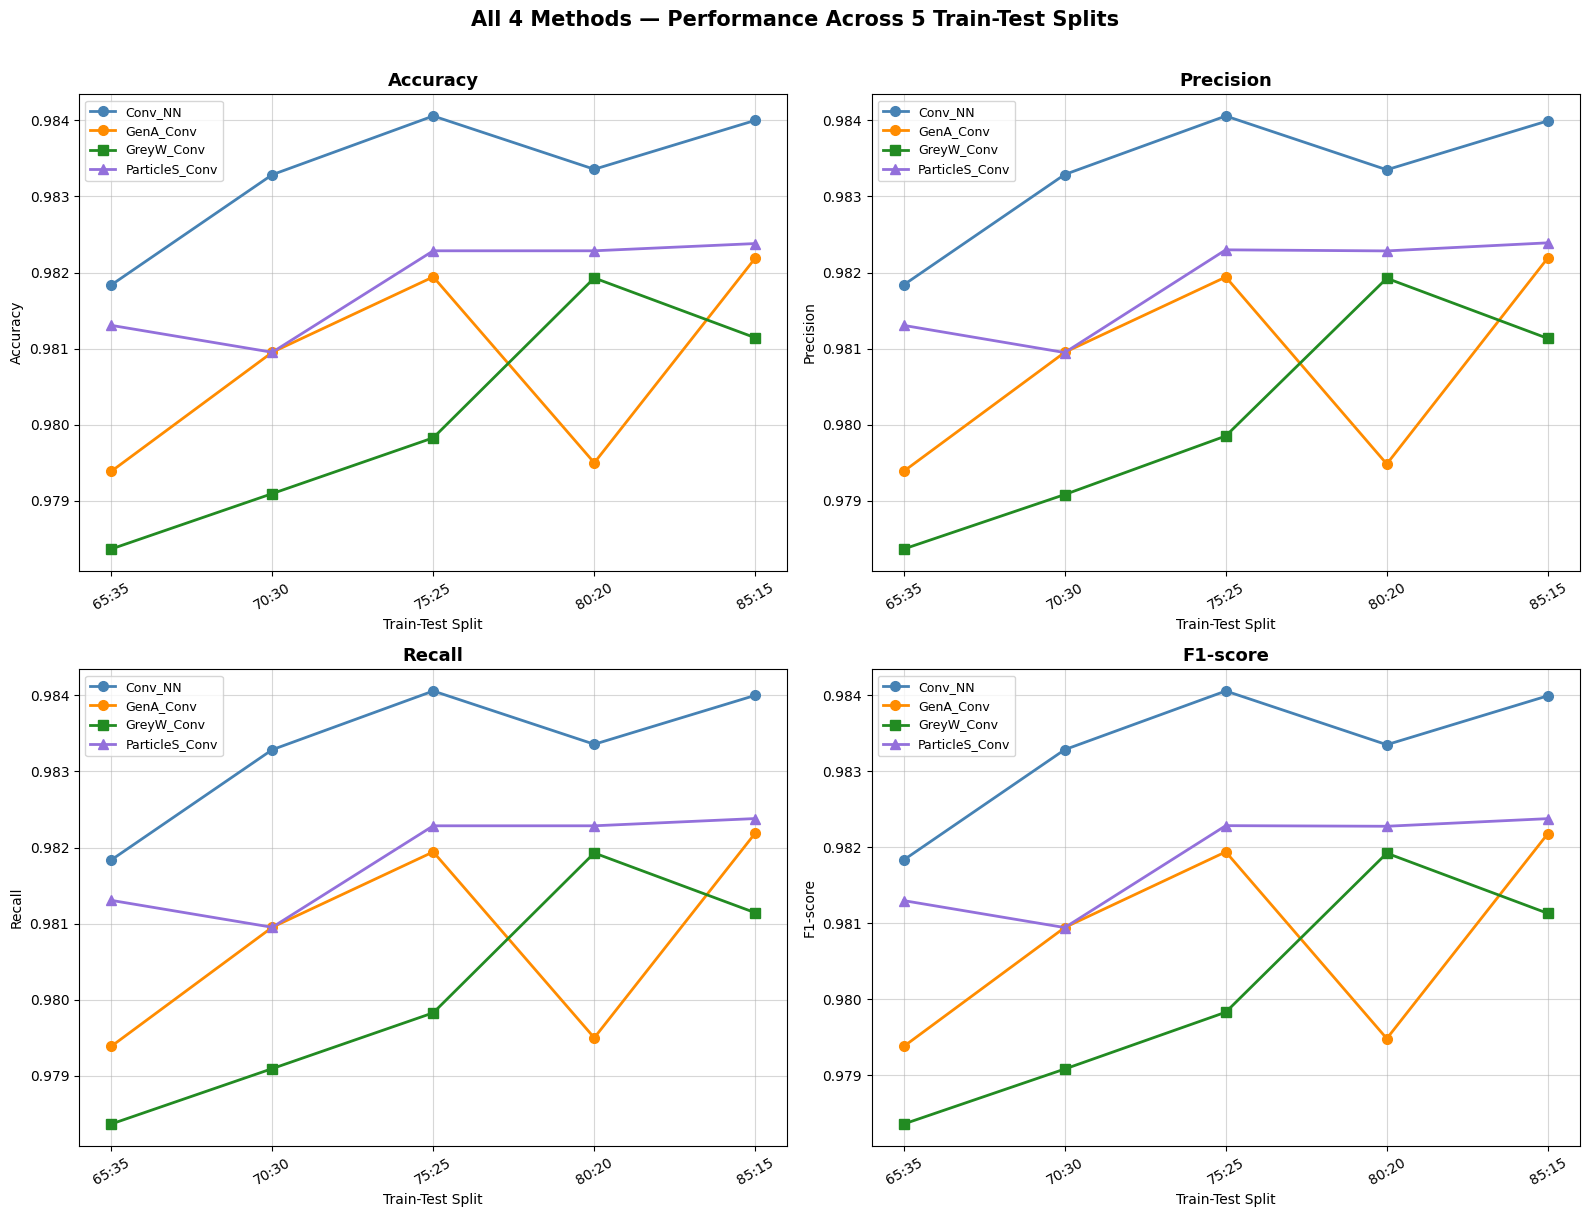

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
colors  = {"Conv_NN":"steelblue","GenA_Conv":"darkorange",
           "GreyW_Conv":"forestgreen","ParticleS_Conv":"mediumpurple"}
markers = {"Conv_NN":"o","GenA_Conv":"o","GreyW_Conv":"s","ParticleS_Conv":"^"}
split_labels = [f"{int(tr*100)}:{int(te*100)}" for tr, te in splits]

for ax, metric in zip(axes.flatten(), metrics):
    for method in method_order:
        vals = []
        for sp in split_labels:
            row = final_df[(final_df["Split"]==sp) & (final_df["Method"]==method)]
            vals.append(row[metric].values[0] if len(row) > 0 else np.nan)
        ax.plot(split_labels, vals,
                marker=markers[method], label=method,
                color=colors[method], linewidth=2, markersize=7)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel("Train-Test Split"); ax.set_ylabel(metric)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.5)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle("All 4 Methods — Performance Across 5 Train-Test Splits",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

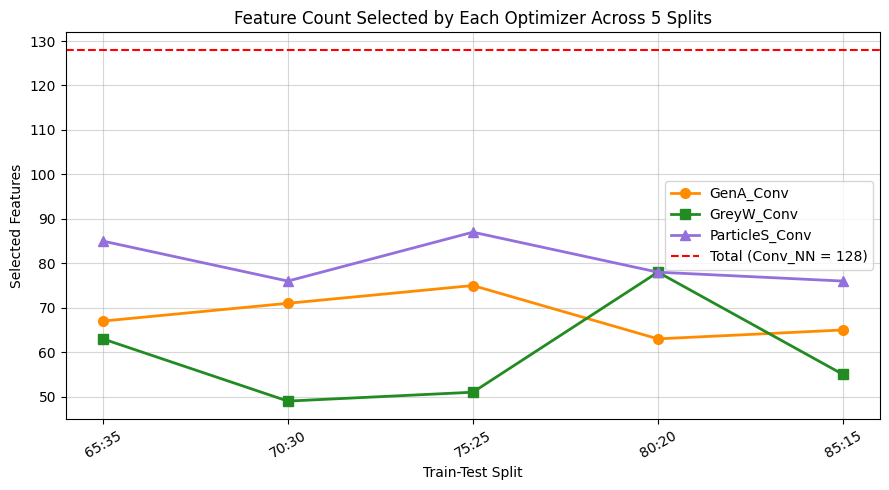

In [44]:
# ── Multi-split selected features trend ──────────────────────────────────
plt.figure(figsize=(9, 5))
for method in ["GenA_Conv", "GreyW_Conv", "ParticleS_Conv"]:
    feat_counts = []
    for sp in split_labels:
        row = final_df[(final_df["Split"]==sp) & (final_df["Method"]==method)]
        feat_counts.append(row["Selected Features"].values[0] if len(row) > 0 else np.nan)
    plt.plot(split_labels, feat_counts,
             marker=markers[method], label=method, color=colors[method], linewidth=2, markersize=7)

plt.axhline(128, color='red', linestyle='--', linewidth=1.5, label='Total (Conv_NN = 128)')
plt.xlabel("Train-Test Split"); plt.ylabel("Selected Features")
plt.title("Feature Count Selected by Each Optimizer Across 5 Splits")
plt.legend(); plt.grid(True, alpha=0.5); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

## Formatted Comparison Table (matches target layout)

Rows: Method × Metric | Columns: Selected Features, 65:35 … 85:15

In [45]:
# Build the table matching the image format
table_rows = []
for method in method_order:
    for metric in ["Accuracy", "Precision", "Recall", "F1-score"]:
        row = {"Method": method, "Classification Metrics": metric}
        # Selected Features — use modal value across splits
        feats_list = []
        for sp in split_labels:
            r = final_df[(final_df["Split"]==sp) & (final_df["Method"]==method)]
            if len(r) > 0:
                feats_list.append(r["Selected Features"].values[0])
        row["Selected Features"] = int(np.median(feats_list)) if feats_list else "-"
        for sp in split_labels:
            r = final_df[(final_df["Split"]==sp) & (final_df["Method"]==method)]
            row[sp] = f"{r[metric].values[0]:.4f}" if len(r) > 0 else "-"
        table_rows.append(row)

comparison_table = pd.DataFrame(table_rows, columns=[
    "Method", "Classification Metrics", "Selected Features"] + split_labels)

print("Formatted Comparison Table:")
comparison_table

Formatted Comparison Table:


,Method,Classification Metrics,Selected Features,65:35,70:30,75:25,80:20,85:15
0,Conv_NN,Accuracy,128,0.9818,0.9833,0.9841,0.9834,0.9840
1,Conv_NN,Precision,128,0.9818,0.9833,0.9841,0.9833,0.9840
2,Conv_NN,Recall,128,0.9818,0.9833,0.9841,0.9834,0.9840
3,Conv_NN,F1-score,128,0.9818,0.9833,0.9841,0.9833,0.9840
4,GenA_Conv,Accuracy,67,0.9794,0.9810,0.9819,0.9795,0.9822
5,GenA_Conv,Precision,67,0.9794,0.9810,0.9819,0.9795,0.9822
6,GenA_Conv,Recall,67,0.9794,0.9810,0.9819,0.9795,0.9822
7,GenA_Conv,F1-score,67,0.9794,0.9809,0.9819,0.9795,0.9822
8,GreyW_Conv,Accuracy,55,0.9784,0.9791,0.9798,0.9819,0.9811
9,GreyW_Conv,Precision,55,0.9784,0.9791,0.9799,0.9819,0.9811


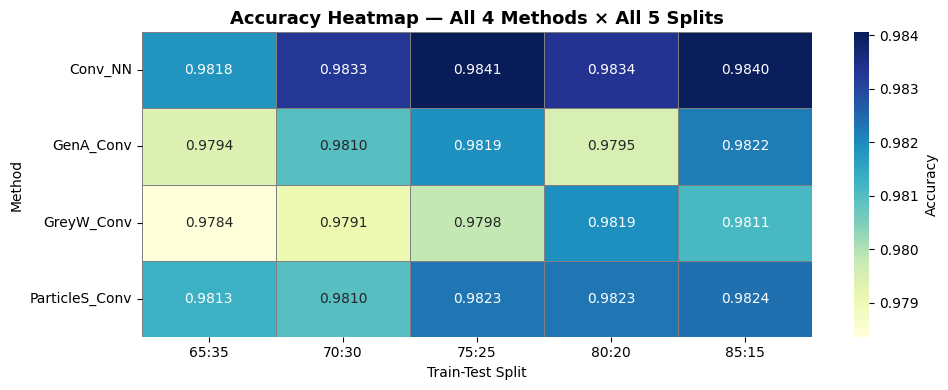

In [46]:
# ── Heatmap-style visualisation of the table ─────────────────────────────
pivot_acc = final_df[final_df["Accuracy"].notna()].pivot_table(
    index="Method", columns="Split", values="Accuracy")
# Reorder columns
pivot_acc = pivot_acc[[sp for sp in split_labels if sp in pivot_acc.columns]]

plt.figure(figsize=(10, 4))
sns.heatmap(pivot_acc, annot=True, fmt=".4f", cmap="YlGnBu",
            linewidths=0.5, linecolor='gray',
            cbar_kws={"label": "Accuracy"})
plt.title("Accuracy Heatmap — All 4 Methods × All 5 Splits", fontsize=13, fontweight='bold')
plt.ylabel("Method"); plt.xlabel("Train-Test Split")
plt.tight_layout(); plt.show()

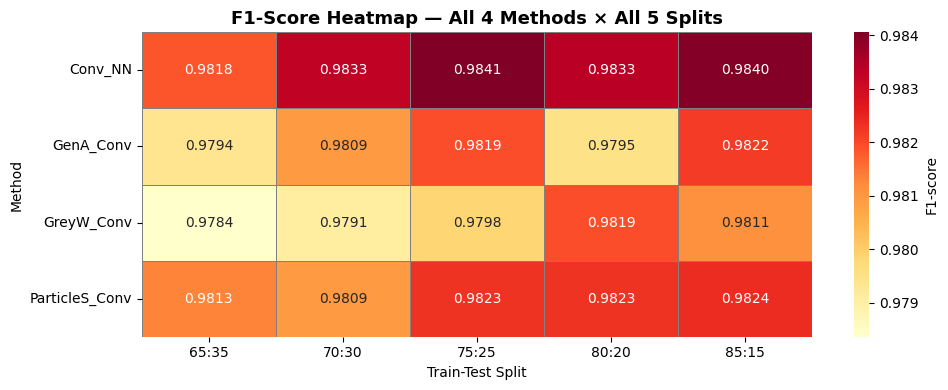

In [47]:
# ── F1-score heatmap ─────────────────────────────────────────────────────
pivot_f1 = final_df[final_df["F1-score"].notna()].pivot_table(
    index="Method", columns="Split", values="F1-score")
pivot_f1 = pivot_f1[[sp for sp in split_labels if sp in pivot_f1.columns]]

plt.figure(figsize=(10, 4))
sns.heatmap(pivot_f1, annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.5, linecolor='gray',
            cbar_kws={"label": "F1-score"})
plt.title("F1-Score Heatmap — All 4 Methods × All 5 Splits", fontsize=13, fontweight='bold')
plt.ylabel("Method"); plt.xlabel("Train-Test Split")
plt.tight_layout(); plt.show()

## Optimizer Convergence Comparison (80:20 split)

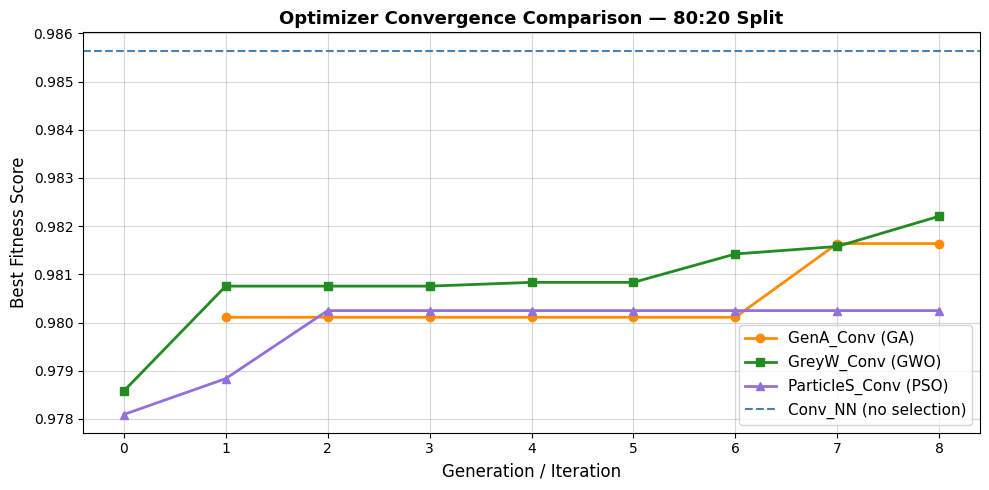

In [48]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(ga_history)+1),  ga_history,  marker='o', color='darkorange',
         linewidth=2, label='GenA_Conv (GA)')
plt.plot(range(len(gwo_history)),       gwo_history, marker='s', color='forestgreen',
         linewidth=2, label='GreyW_Conv (GWO)')
plt.plot(range(len(pso_history)),       pso_history, marker='^', color='mediumpurple',
         linewidth=2, label='ParticleS_Conv (PSO)')
plt.axhline(conv_nn_acc, color='steelblue', linestyle='--', linewidth=1.5, label='Conv_NN (no selection)')

plt.xlabel("Generation / Iteration", fontsize=12)
plt.ylabel("Best Fitness Score", fontsize=12)
plt.title("Optimizer Convergence Comparison — 80:20 Split", fontsize=13, fontweight='bold')
plt.legend(fontsize=11); plt.grid(True, alpha=0.5); plt.tight_layout(); plt.show()

## Confusion Matrices — Best Split Results (80:20)

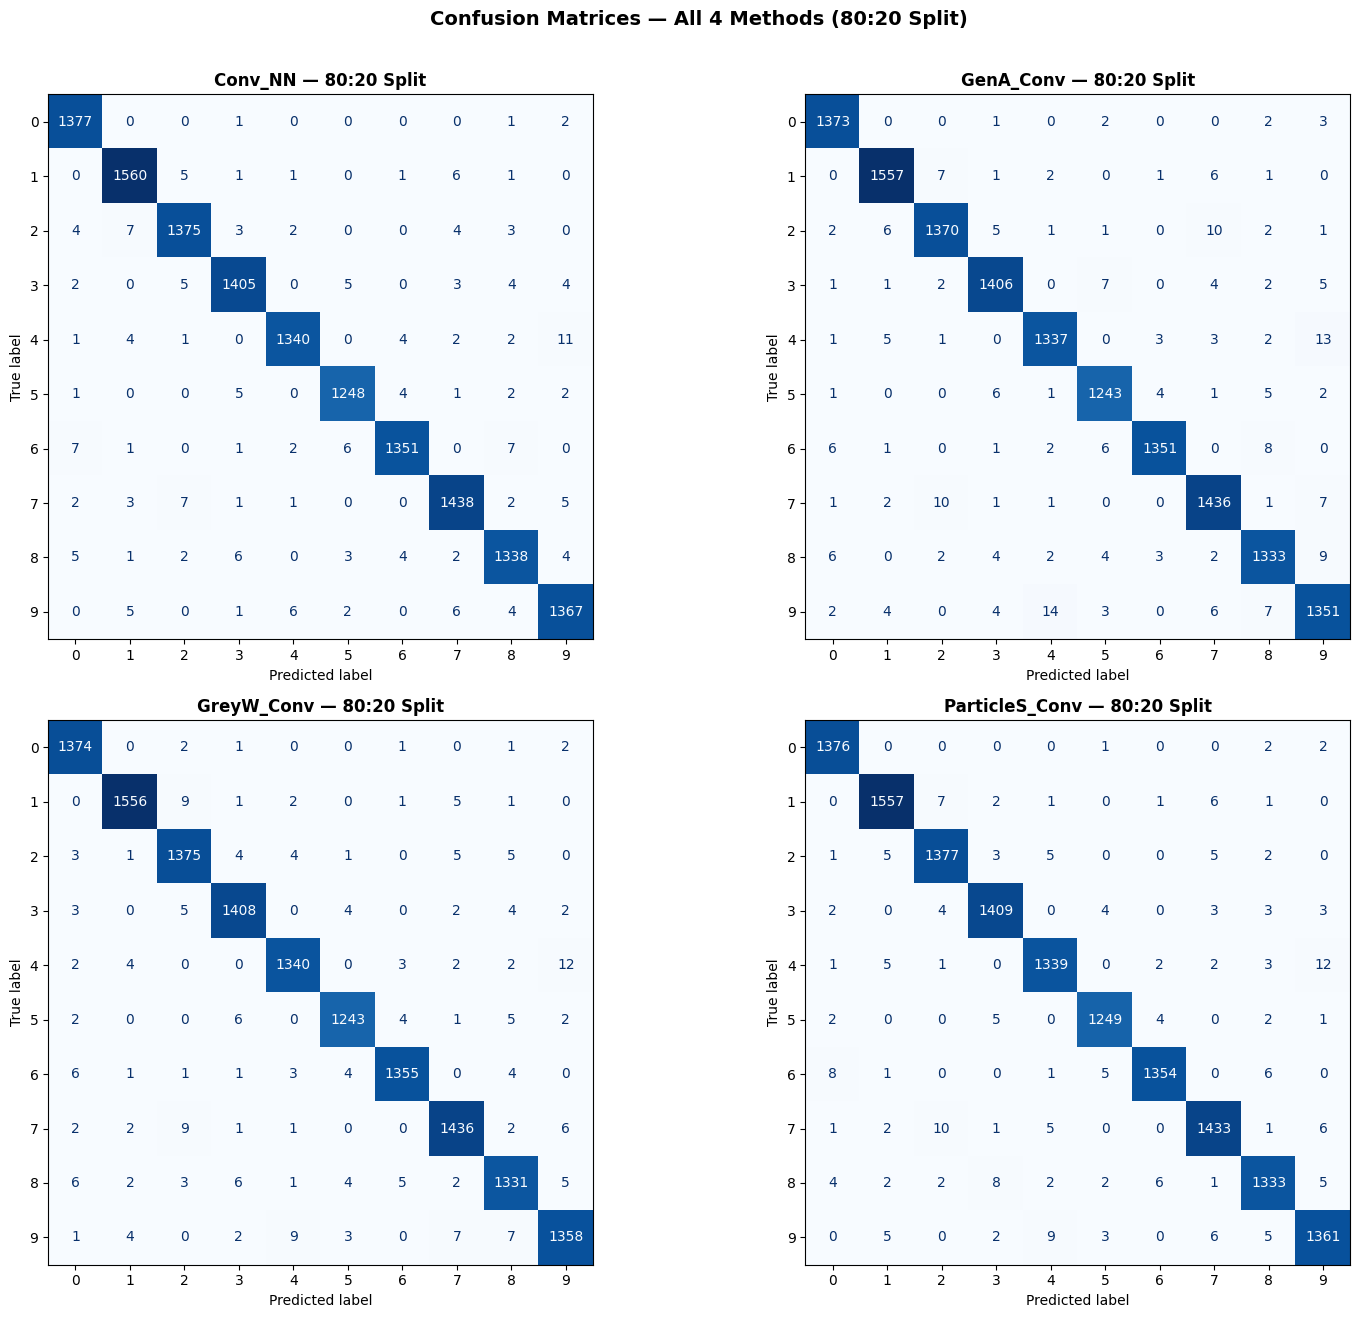

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
preds_map = {
    "Conv_NN": conv_nn_preds,
    "GenA_Conv": gena_preds,
    "GreyW_Conv": greyw_preds,
    "ParticleS_Conv": particles_preds
}
for ax, method in zip(axes.flatten(), method_order):
    preds = preds_map[method]
    cm = confusion_matrix(y_test_features, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=list(range(10)))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{method} — 80:20 Split", fontsize=12, fontweight='bold')
plt.suptitle("Confusion Matrices — All 4 Methods (80:20 Split)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## Best Method Selection

In [50]:
# Score each method: mean rank across Accuracy, F1, feature reduction
method_scores = {}
for method in method_order:
    sub = final_df[final_df["Method"]==method]
    mean_acc = sub["Accuracy"].mean()
    mean_f1  = sub["F1-score"].mean()
    mean_feats = sub["Selected Features"].mean()
    # Feature reduction bonus: fewer features → better score (normalized to 0-1)
    feat_score = 1 - (mean_feats / 128)
    # Composite score: 40% accuracy + 40% F1 + 20% feature reduction
    composite = 0.40 * mean_acc + 0.40 * mean_f1 + 0.20 * feat_score
    method_scores[method] = {
        "Mean Accuracy": mean_acc,
        "Mean F1-score": mean_f1,
        "Mean Features Selected": mean_feats,
        "Feature Reduction %": f"{feat_score*100:.1f}%",
        "Composite Score": composite
    }

scores_df = pd.DataFrame(method_scores).T.sort_values("Composite Score", ascending=False)
scores_df["Composite Score"] = scores_df["Composite Score"].astype(float).round(5)
print(scores_df)
best_method = scores_df.index[0]
print(f"\n>>> Best overall method: {best_method} <<<")

               Mean Accuracy Mean F1-score Mean Features Selected  \
GreyW_Conv          0.980073      0.980066                   59.2   
GenA_Conv           0.980795      0.980786                   68.2   
ParticleS_Conv      0.981842      0.981835                   80.4   
Conv_NN             0.983307      0.983301                  128.0   

               Feature Reduction %  Composite Score  
GreyW_Conv                   53.8%          0.89156  
GenA_Conv                    46.7%          0.87807  
ParticleS_Conv               37.2%          0.85985  
Conv_NN                       0.0%          0.78664  

>>> Best overall method: GreyW_Conv <<<


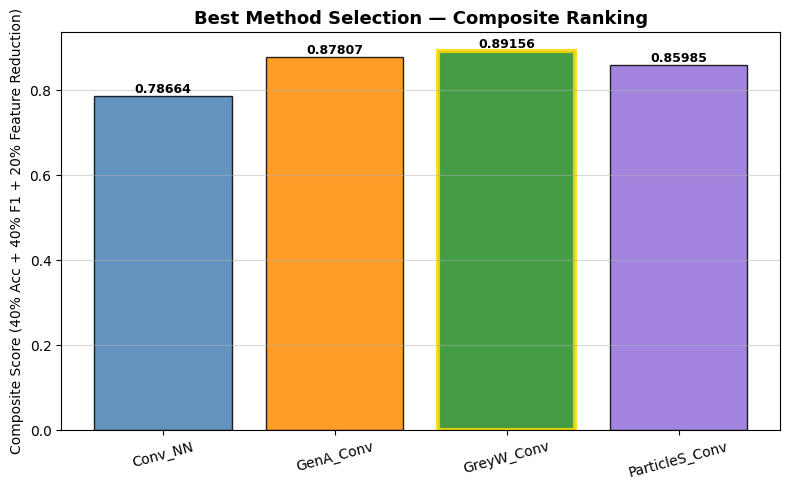

Winner: GreyW_Conv


In [51]:
fig, ax = plt.subplots(figsize=(8, 5))
composite_vals = [float(scores_df.loc[m,"Composite Score"]) for m in method_order]
bar_colors_list = [colors[m] for m in method_order]
bars = ax.bar(method_order, composite_vals, color=bar_colors_list, edgecolor='black', alpha=0.85)
ax.set_ylabel("Composite Score (40% Acc + 40% F1 + 20% Feature Reduction)")
ax.set_title("Best Method Selection — Composite Ranking", fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.5)
for bar, v in zip(bars, composite_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0002,
            f"{v:.5f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
# Highlight best
best_idx = method_order.index(best_method)
bars[best_idx].set_edgecolor('gold'); bars[best_idx].set_linewidth(3)
plt.xticks(rotation=15); plt.tight_layout(); plt.show()
print(f"Winner: {best_method}")

## Correlation Heatmaps — Selected Features for Each Method (80:20)

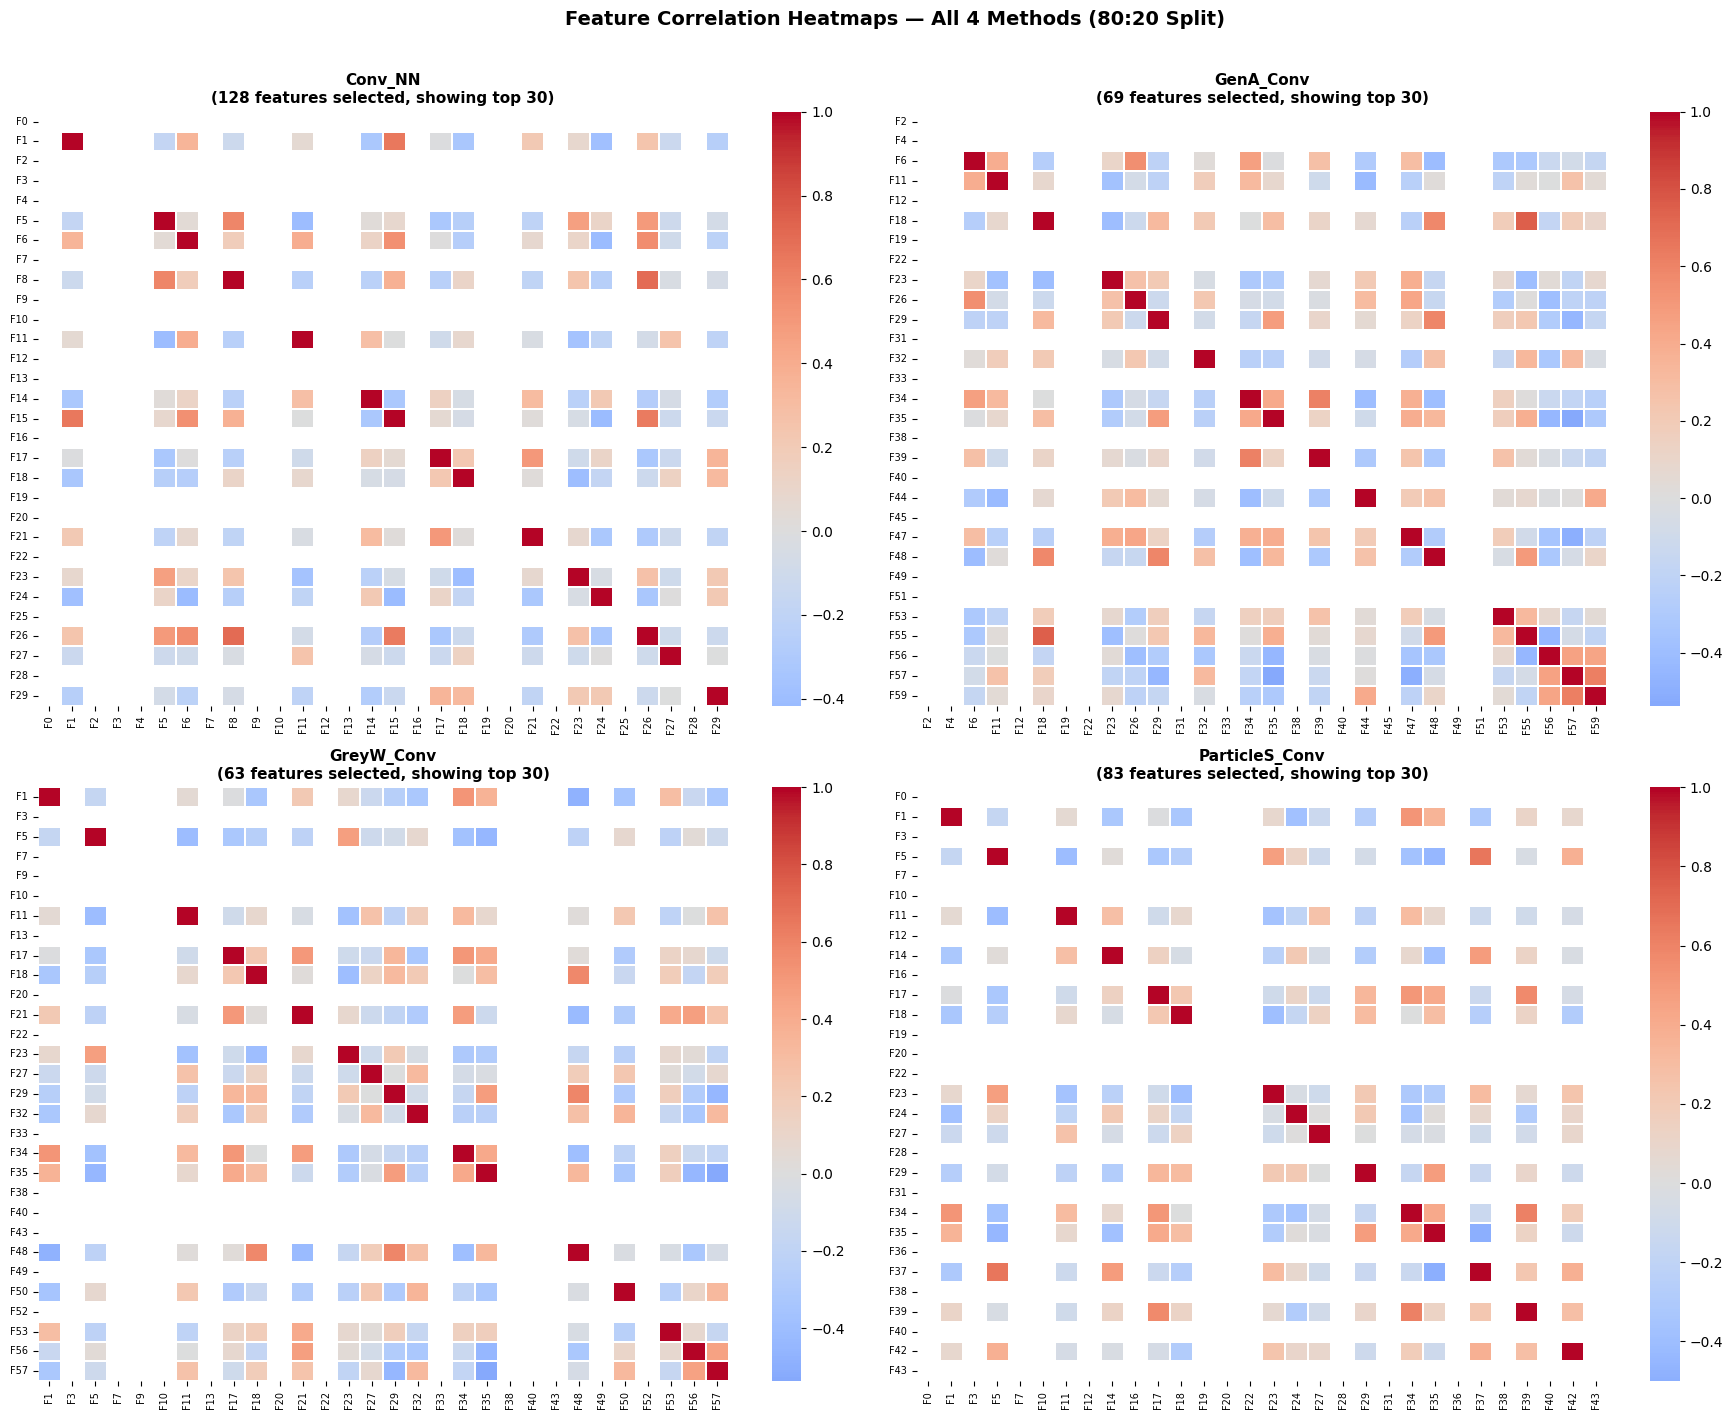

In [52]:
selected_feature_map = {
    "Conv_NN": list(range(128)),     # all 128
    "GenA_Conv": list(ga_selected_features),
    "GreyW_Conv": list(gwo_selected_features),
    "ParticleS_Conv": list(pso_selected_features)
}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, method in zip(axes.flatten(), method_order):
    sel = selected_feature_map[method]
    max_for_heatmap = 30
    if len(sel) > max_for_heatmap:
        sel_h = sel[:max_for_heatmap]
    else:
        sel_h = sel
    feat_names = [f"F{i}" for i in sel_h]
    X_sel = X_train_features_scaled[:, sel_h]
    corr_df = pd.DataFrame(X_sel, columns=feat_names)
    corr_mat = corr_df.corr()
    sns.heatmap(corr_mat, ax=ax, cmap="coolwarm", center=0,
                annot=(len(sel_h) <= 15),
                fmt=".2f" if len(sel_h) <= 15 else "",
                linewidths=0.3, cbar=True)
    ax.set_title(f"{method}\n({len(sel)} features selected, showing top {len(sel_h)})",
                 fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle("Feature Correlation Heatmaps — All 4 Methods (80:20 Split)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## SHAP Value Analysis — Best Method

In [53]:
import shap

shap_feat_map = {
    "Conv_NN":       (conv_nn_model,   list(range(128))),
    "GenA_Conv":     (gena_model,      list(ga_selected_features)),
    "GreyW_Conv":    (greyw_model,     list(gwo_selected_features)),
    "ParticleS_Conv":(particles_model, list(pso_selected_features))
}

best_model_shap, best_sel_feats = shap_feat_map[best_method]
X_bg   = X_train_features_scaled[:300, best_sel_feats]
X_expl = X_test_features_scaled[:300,  best_sel_feats]
feat_names_shap = [f"F{i}" for i in best_sel_feats]

explainer   = shap.LinearExplainer(best_model_shap, X_bg)
shap_values = explainer.shap_values(X_expl)
print(f"SHAP analysis for best method: {best_method}")
print(f"Features analysed: {len(best_sel_feats)}")

SHAP analysis for best method: GreyW_Conv
Features analysed: 63


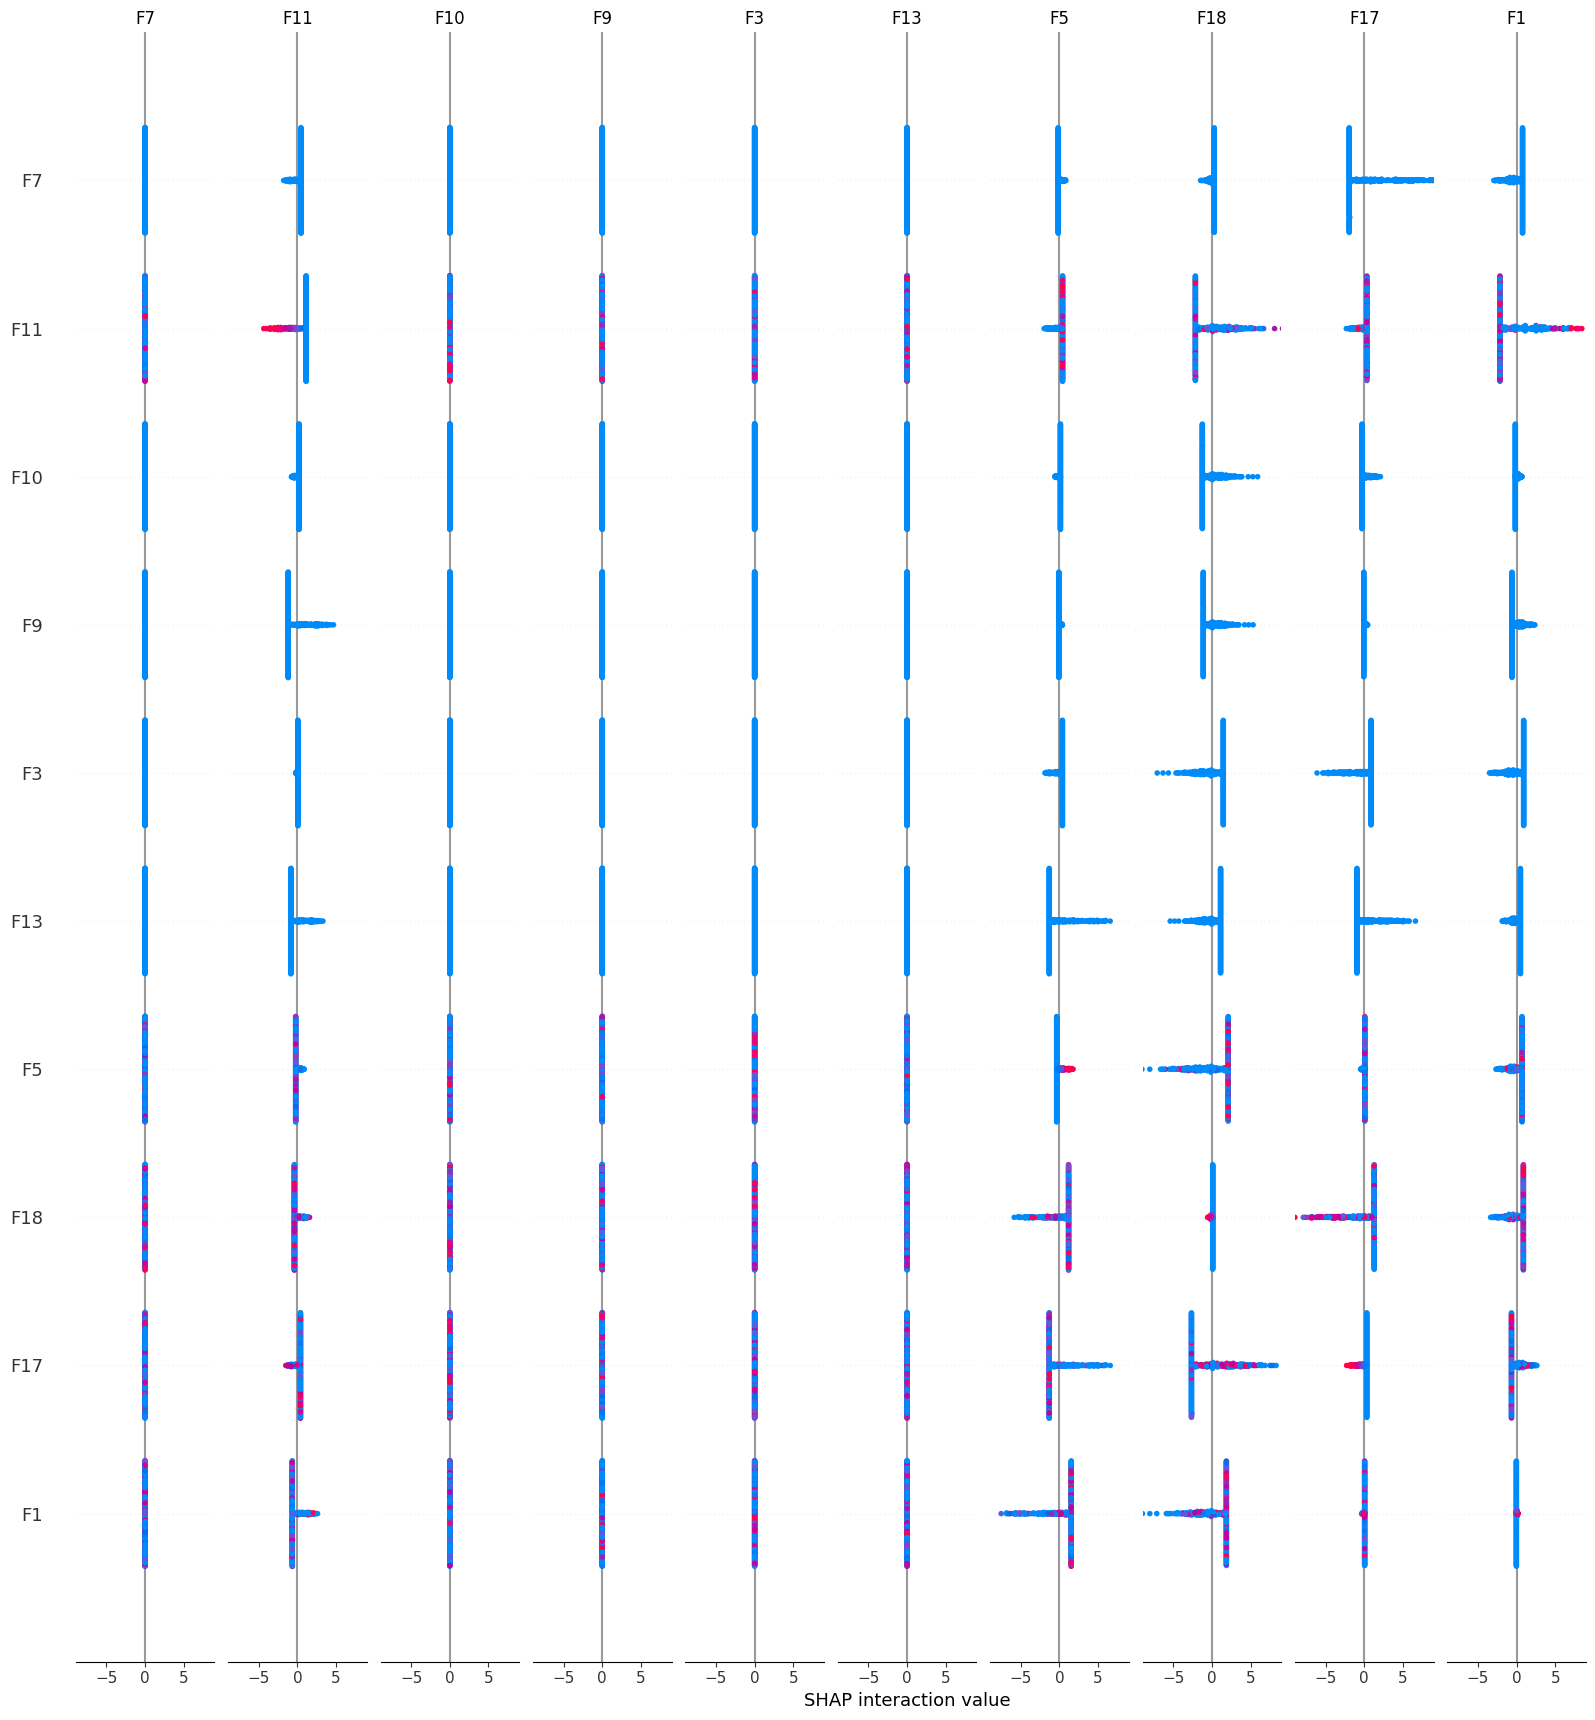

In [54]:
# ── SHAP beeswarm summary ─────────────────────────────────────────────────
shap.summary_plot(shap_values, X_expl, feature_names=feat_names_shap,
                  plot_type="dot", max_display=20,
                  title=f"SHAP Summary — {best_method} (80:20 Split)")

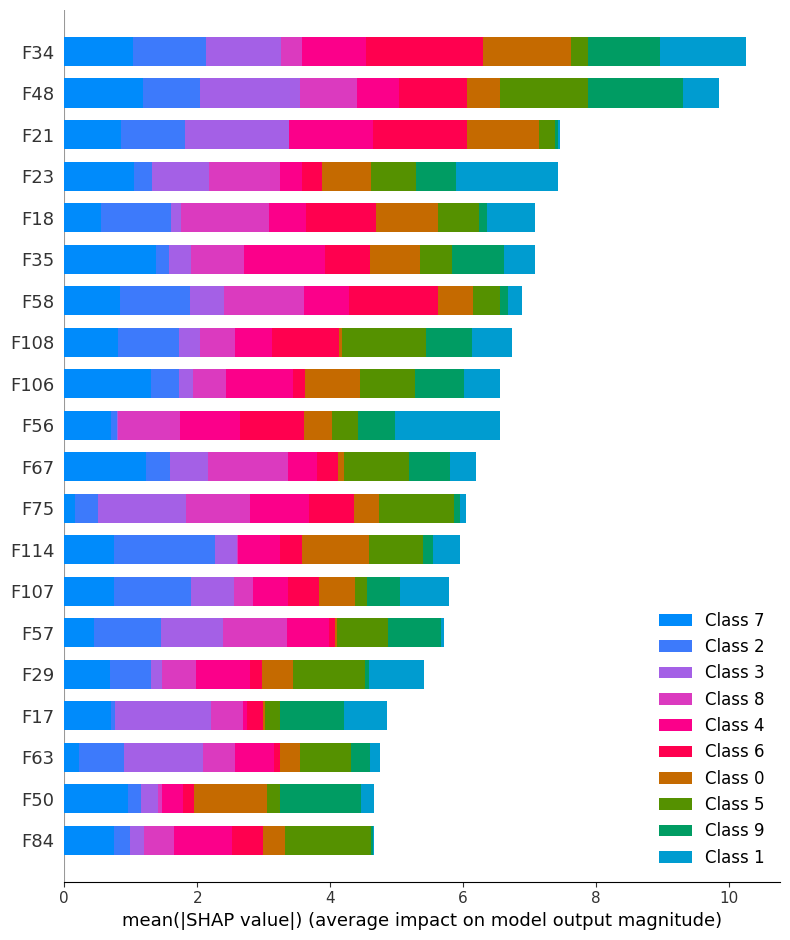

In [55]:
# ── SHAP bar plot: mean |SHAP| per feature ────────────────────────────────
shap.summary_plot(shap_values, X_expl, feature_names=feat_names_shap,
                  plot_type="bar", max_display=20,
                  title=f"SHAP Feature Importance — {best_method}")